<hr>

**<h1><b>  Optimizers and Autoencoders Experiments</b></h1>**

<hr>

#

In [1]:
# ============ Import Libraries =============
import warnings
warnings.filterwarnings('ignore')
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns
from torchsummary import summary
import random
import matplotlib.pyplot as plt
import torchvision.utils as vutils
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix, adjusted_rand_score, normalized_mutual_info_score

# =========== Experiment Information ===========
Name = "Muaaz"
Experiment_ID = "26100117"

# =========== Device Configuration ==========
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') # GPU is available or not
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu') # MPS is available or not - Only for Macbook M1 and above
print(f"Device: {device}")

# =========== Visualization Function ==========
def imshow(img, dataset_name):
    img = img
    npimg = img.numpy()
    plt.figure(figsize=(10, 10))
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')
    plt.title(f"Random Batch of Images from the {dataset_name} Dataset")
    plt.show()
    

Device: mps


<hr>

## <h1><b> Part 2: Autoencoder Architectures: Reconstruction and Denoising</b></h1>  

<hr>

### <h2><b> Introduction </b></h2>  
<p>Autoencoders are a type of <b>unsupervised neural network</b> designed to learn efficient data representations. They consist of two main components:</p>  
<ul>  
    <li><b>Encoder:</b> Compresses the input into a lower-dimensional latent space.</li>  
    <li><b>Decoder:</b> Reconstructs the original input from the encoded representation.</li>  
</ul>  

<p>This structure makes autoencoders useful for various tasks, including:</p>  
<ul>  
    <li>Dimensionality reduction</li>
    <li>Noise removal (denoising autoencoders)</li>  
    <li>Anomaly detection</li>  
    <li>Feature extraction for downstream tasks</li>  
</ul>

<hr>  

<h2><b> Linear and Convolutional Autoencoders </b></h2>  
<p>In this task, we explore two types of autoencoders:</p>  

<ul>
    <li><b>Linear Autoencoder:</b> Uses fully connected layers and learns a compressed representation of the input in a linear fashion, often simpler and less computationally intensive than convolutional variants.</li>
    <li><b>Convolutional Autoencoder (CAE):</b> Replaces fully connected layers with <b>convolutional layers</b>, making it more effective for image processing. CAEs leverage spatial hierarchies in images, capturing key features while preserving important structures.</li>    
</ul>

<hr>  

<h2><b> CIFAR-10 and MNIST Datasets </b></h2>  
<p>The <b>CIFAR-10 dataset</b> is a commonly used benchmark dataset for deep learning research. It consists of <b>60,000 color images</b> (32x32 pixels), divided into <b>10 classes</b> representing different objects:</p>  

<table border="1" cellpadding="10" cellspacing="0" style="border-collapse: collapse; text-align: center;">  
    <tr style="background-color:rgb(60, 60, 60);">  
        <th><b>Class</b></th>  
        <th>Airplane</th>  
        <th>Automobile</th>  
        <th>Bird</th>  
        <th>Cat</th>  
        <th>Deer</th>  
        <th>Dog</th>  
        <th>Frog</th>  
        <th>Horse</th>  
        <th>Ship</th>  
        <th>Truck</th>  
    </tr>  
    <tr>  
        <th style="background-color:rgb(60, 60, 60);"><b>Label</b></th>  
        <td>0</td>  
        <td>1</td>  
        <td>2</td>  
        <td>3</td>  
        <td>4</td>  
        <td>5</td>  
        <td>6</td>  
        <td>7</td>  
        <td>8</td>  
        <td>9</td>  
    </tr>  
</table>  

<p>The <b>MNIST dataset</b> contains <b>60,000 grayscale images</b> (28x28 pixels) of handwritten digits, divided into <b>10 classes</b> (digits 0-9), used primarily for digit classification and image reconstruction tasks.</p>  

<hr>

<h2><b> Objectives </b></h2>  

<ul>  
    <li>Implement an <b>Autoencoder</b> using two architectures: <b>Linear Autoencoder</b> and <b>Convolutional Autoencoder (CNN)</b>.</li>  
    <li>Design and implement <b>Encoder</b> and <b>Decoder</b> modules in PyTorch.</li>  
    <li>Train the models on <b>CIFAR-10</b> and <b>MNIST</b> datasets, evaluating their reconstruction quality.</li>  
    <li>Test the Autoencoders in <b>six scenarios</b>, each demonstrating a key application:</li>  
    <ul>
        <li>Linear Autoencoder - Reconstruction (CIFAR-10)</li>
        <li>Convolutional Autoencoder - Reconstruction (CIFAR-10)</li>
        <li>Linear Autoencoder - Denoising (MNIST)</li>
        <li>Convolutional Autoencoder - Denoising (MNIST)</li>
        <li>CNN Image Classification Analysis - CIFAR-10 Reconstruction</li>
        <li>CNN Image Classification Analysis - MNIST Denoising</li>
    </ul>
    <li>Extend the applications by implementing <b>Task 7: Generating Images using Latent Space</b> for advanced understanding and performance evaluation.</li>
</ul>  

<br>

<table border="1" cellpadding="10" cellspacing="0" width="100%">  
    <tr>  
        <th><b>Scenario</b></th>  
        <th><b>Description</b></th>  
        <th><b>Purpose</b></th>  
    </tr>  
    <tr>  
        <td><b>1. Linear Autoencoder - Reconstruction (CIFAR-10)</b></td>  
        <td>Train and test a linear autoencoder on the CIFAR-10 dataset for image reconstruction.</td>  
        <td>Demonstrates the ability of a linear autoencoder to learn compressed representations and reconstruct images from CIFAR-10.</td>  
    </tr>  
    <tr>  
        <td><b>2. Convolutional Autoencoder - Reconstruction (CIFAR-10)</b></td>  
        <td>Train and test a convolutional autoencoder on CIFAR-10 images for image reconstruction.</td>  
        <td>Shows how convolutional layers can capture spatial features and improve reconstruction performance on CIFAR-10.</td>  
    </tr>  
    <tr>  
        <td><b>3. Linear Autoencoder - Denoising (MNIST)</b></td>  
        <td>Train the model on noisy MNIST images and test its ability to reconstruct clean images.</td>  
        <td>Demonstrates how a linear autoencoder can filter noise and recover the original images from noisy inputs.</td>  
    </tr>  
    <tr>  
        <td><b>4. Convolutional Autoencoder - Denoising (MNIST)</b></td>  
        <td>Train the convolutional autoencoder on noisy MNIST digits and test its denoising capabilities.</td>  
        <td>Shows how convolutional autoencoders can better denoise images by leveraging spatial hierarchies in image data.</td>  
    </tr>
    <tr>  
        <td><b>5. CNN Image Classification Analysis - CIFAR-10 Reconstruction</b></td>  
        <td>Train a CNN on clean CIFAR-10 images and evaluate its performance on the original test data, LAERecon reconstructed test data, and CAERecon reconstructed test data.</td>  
        <td>Assesses how well the reconstructions preserve essential features for classification.</td>  
    </tr>  
    <tr>  
        <td><b>6. CNN Image Classification Analysis - MNIST Denoising</b></td>  
        <td>Train a CNN on clean MNIST images and evaluate its performance on the original test data, LAEDenoise reconstructed test data, and CAEDenoise reconstructed test data.</td>  
        <td>Assesses how well the denoising reconstructions preserve essential features for classification.</td>  
    </tr>  
    <tr>  
        <td><b>7. Generating Images using Latent Space</b></td>  
        <td>Sample random vectors from the latent space and pass them through the decoder to generate new images.</td>  
        <td>Evaluate the potential of autoencoders for generating realistic images from latent space representations.</td>  
    </tr>  
</table>  

<br>  

<p>This task will test the ability to build and apply Autoencoders in PyTorch, explore feature learning, and analyze their performance across different real-world applications.</p>

<hr>

<hr>

## <h1><b> Hyper<span style="color: #9370DB;">parameters</span></b></h1>  

<hr>

In [75]:
BATCH_SIZE = 128
EPOCHS = 10
LEARNING_RATE = 0.001

# =========== Results Dictionary (To be updated and printed at the end) ==========

Overall_Results = {
  "Task 1": {
    "Train Loss (Last Epoch)": 0.0034,
    "Test Loss (Last Epoch)": 0.0035,
    "Train Loss (Minimum)": 0.0034,
    "Test Loss (Minimum)": 0.0033
  },
  "Task 2": {
    "Train Loss (Last Epoch)": 0.001,
    "Test Loss (Last Epoch)": 0.0009,
    "Train Loss (Minimum)": 0.001,
    "Test Loss (Minimum)": 0.0009
  },
  "Task 3": {
    "Train Loss (Last Epoch)": 0.2455,
    "Test Loss (Last Epoch)": 0.2454,
    "Train Loss (Minimum)": 0.2454,
    "Test Loss (Minimum)": 0.2451
  },
  "Task 4": {
    "Train Loss (Last Epoch)": 0.1855,
    "Test Loss (Last Epoch)": 0.1853,
    "Train Loss (Minimum)": 0.1855,
    "Test Loss (Minimum)": 0.1853
  },
  "Task 5": {
    "Train Loss (Last Epoch)": 0.0595,
    "Test Loss (Last Epoch)": 1.912,
    "Train Accuracy (Last Epoch)": 0.9799,
    "Test Accuracy (Last Epoch)": 0.7232,
    "Train Loss (Minimum)": 0.0595,
    "Test Loss (Minimum)": 0.7716,
    "Train Accuracy (Maximum)": 0.9799,
    "Test Accuracy (Maximum)": 0.732
  },
  "Task 6": {
    "Train Loss (Last Epoch)": 0.0089,
    "Test Loss (Last Epoch)": 0.0282,
    "Train Accuracy (Last Epoch)": 0.9972,
    "Test Accuracy (Last Epoch)": 0.9913,
    "Train Loss (Minimum)": 0.0089,
    "Test Loss (Minimum)": 0.0282,
    "Train Accuracy (Maximum)": 0.9972,
    "Test Accuracy (Maximum)": 0.9915
  }
}

print(Overall_Results)

{'Task 1': {'Train Loss (Last Epoch)': 0.0034, 'Test Loss (Last Epoch)': 0.0035, 'Train Loss (Minimum)': 0.0034, 'Test Loss (Minimum)': 0.0033}, 'Task 2': {'Train Loss (Last Epoch)': 0.001, 'Test Loss (Last Epoch)': 0.0009, 'Train Loss (Minimum)': 0.001, 'Test Loss (Minimum)': 0.0009}, 'Task 3': {'Train Loss (Last Epoch)': 0.2455, 'Test Loss (Last Epoch)': 0.2454, 'Train Loss (Minimum)': 0.2454, 'Test Loss (Minimum)': 0.2451}, 'Task 4': {'Train Loss (Last Epoch)': 0.1855, 'Test Loss (Last Epoch)': 0.1853, 'Train Loss (Minimum)': 0.1855, 'Test Loss (Minimum)': 0.1853}, 'Task 5': {'Train Loss (Last Epoch)': 0.0595, 'Test Loss (Last Epoch)': 1.912, 'Train Accuracy (Last Epoch)': 0.9799, 'Test Accuracy (Last Epoch)': 0.7232, 'Train Loss (Minimum)': 0.0595, 'Test Loss (Minimum)': 0.7716, 'Train Accuracy (Maximum)': 0.9799, 'Test Accuracy (Maximum)': 0.732}, 'Task 6': {'Train Loss (Last Epoch)': 0.0089, 'Test Loss (Last Epoch)': 0.0282, 'Train Accuracy (Last Epoch)': 0.9972, 'Test Accuracy (

<hr>

## <h1><b> Dataset Loading |<span style="color: #9370DB;"> CIFAR-10</span></b></h1>  

<hr>

In [3]:
# ============== Data Preprocessing ==================
transform = transforms.Compose([
    transforms.ToTensor()
])

# ================ Data Loading ======================
CIFAR_10_trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
CIFAR_10_trainloader = torch.utils.data.DataLoader(
    CIFAR_10_trainset, 
    batch_size=BATCH_SIZE,    
    shuffle=True,       
    num_workers=2
)

CIFAR_10_testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
CIFAR_10_testloader = torch.utils.data.DataLoader(
    CIFAR_10_testset, 
    batch_size=BATCH_SIZE, 
    shuffle=False,      
    num_workers=2       
)

<hr>

## <h1><b> Dataset Loading |<span style="color: #9370DB;"> MINST</span></b></h1>  

<hr>

In [5]:
# ============== Data Preprocessing ==================
transform = transforms.Compose([
    transforms.ToTensor()
])

transform_noisy = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x + 0.5 * torch.randn_like(x))
])

# ================ Data Loading ======================
MNIST_trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
MNIST_trainloader = torch.utils.data.DataLoader(
    MNIST_trainset,
    batch_size=BATCH_SIZE,      
    shuffle=True
)

MNIST_testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
MNIST_testloader = torch.utils.data.DataLoader(
    MNIST_testset,
    batch_size=BATCH_SIZE,     
    shuffle=False        
)

MNIST_trainset_noisy = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform_noisy)
MNIST_trainloader_noisy = torch.utils.data.DataLoader(
    MNIST_trainset_noisy,
    batch_size=BATCH_SIZE,
    shuffle=True
)

MNIST_testset_noisy = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform_noisy)
MNIST_testloader_noisy = torch.utils.data.DataLoader(
    MNIST_testset_noisy,
    batch_size=BATCH_SIZE,
    shuffle=False
)

<hr>

## <h1><b> Data Visualisation |<span style="color: #9370DB;"> CIFAR-10</span></b></h1>  

<hr>

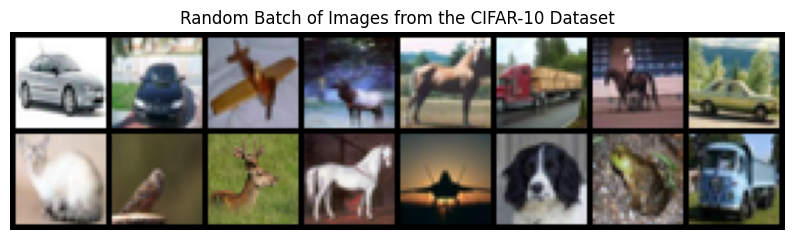

In [6]:
dataiter = iter(CIFAR_10_trainloader)
images, _ = next(dataiter)
imshow(torchvision.utils.make_grid(images[0:16]), "CIFAR-10")

<hr>

## <h1><b> Data Visualisation |<span style="color: #9370DB;"> MINST</span></b></h1>  

<hr>

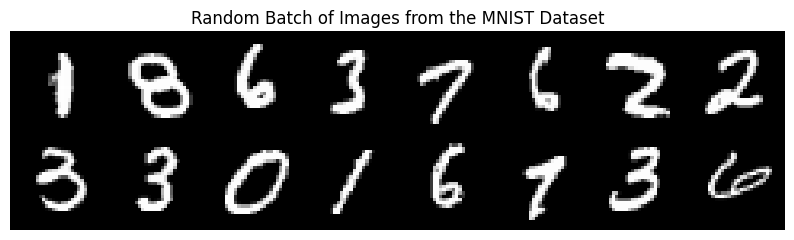

In [7]:
dataiter = iter(MNIST_trainloader)
images, _ = next(dataiter)
imshow(torchvision.utils.make_grid(images[0:16]), "MNIST")

<hr>

## <h1><b> Data Visualisation |<span style="color: #9370DB;"> MINST - Noisy</span></b></h1>  

<hr>

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


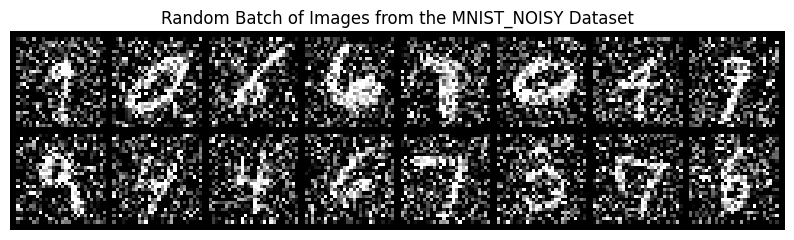

In [8]:
dataiter = iter(MNIST_trainloader_noisy)
images, _ = next(dataiter)
imshow(torchvision.utils.make_grid(images[0:16]), "MNIST_NOISY")

<hr>

## <h1 style="text-align: left;"><b>Task 1: Linear Autoencoder Reconstruction | <span style="color: #9370DB;">CIFAR-10</span></b></h1>

<hr>

### <h2>1. In a Linear Autoencoder (LAE):</h2>

<ul>
    <li>The <b>encoder</b> primarily uses <code>Linear</code> layers to compress the input into a lower-dimensional latent space.</li>
    <li>The <b>decoder</b> utilizes <code>Linear</code> layers to reconstruct the original input from the latent space.</li>
</ul>

<hr>

<h2>2. Fully Connected Layers in a Linear Autoencoder</h2>

<table border="1" cellpadding="10" cellspacing="0" width="100%">
    <tr style="background-color:rgb(60, 60, 60);">
        <th style="text-align: left;">Layer</th>
        <th style="text-align: left;">Function</th>
    </tr>
    <tr>
        <td><b>Linear</b></td>
        <td>Applies a fully connected transformation to project the input into a lower-dimensional space (encoding) or reconstruct it back (decoding).</td>
    </tr>
</table>

<p>You can read the PyTorch documentation as well for more information!</p>

<hr>

<h2>3. Understanding Linear Layers</h2>

<h3>Linear Layer</h3>
<p>A <b>Linear Layer</b> applies a fully connected transformation, mapping an input vector to an output vector using weights and biases.</p>
<p><b>Syntax:</b></p>
<pre style="background-color:rgb(60, 60, 60); padding: 10px; border-radius: 5px;">
nn.Linear(in_features, out_features)
</pre>

<ul>
    <li><b>in_features:</b> Number of input features (e.g., flattened image pixels).</li>
    <li><b>out_features:</b> Number of output features (e.g., latent space dimension).</li>
</ul>

<hr>

<hr>

### <h1 style="text-align: left;">Class | <span style="color: #9370DB;">Linear Autoencoder</span></h1>

<hr>

In [9]:
class LinearAutoencoderRecon(nn.Module):
    def __init__(self,inputt, hidden):
        super(LinearAutoencoderRecon, self).__init__()
        # ===================== YOUR CODE HERE ======================
        self.encoder = nn.Linear(inputt, hidden)
        self.decoder = nn.Linear(hidden, inputt)
        # =========================================================== 
        
    def forward(self, x):
        # ===================== YOUR CODE HERE ======================
        batch_size = x.size(0)
        x = x.view(batch_size, -1)  
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        decoded = torch.sigmoid(decoded)  
        decoded = decoded.view(batch_size, 3, 32, 32)  
        return decoded
        # =========================================================== 

<hr>

### <h1 style="text-align: left;">Class | <span style="color: #9370DB;">LAERecon</span></h1>

<hr>

### <p><strong>Overview:</strong><br>
The <code>LAERecon</code> is a class designed to facilitate the training, evaluation, and visualization of a <strong>Linear Autoencoder (LAE)</strong> model. It manages the training loop, computes losses, performs evaluations, and visualizes reconstructions to monitor model performance. The class also includes methods for saving and loading the model.</p>

---

<h3>Constructor (<code>__init__</code>):</h3>
<p>The constructor initializes key components:</p>
<ul>
  <li><code>model (nn.Module)</code>: The Linear Autoencoder model.</li>
  <li><code>train_loader (DataLoader)</code>: The training dataset loader.</li>
  <li><code>test_loader (DataLoader)</code>: The test dataset loader.</li>
  <li><code>lr (float)</code>: Learning rate for the optimizer (default <code>0.001</code>).</li>
  <li><code>num_epochs (int)</code>: Number of training epochs (default <code>20</code>).</li>
  <li><code>device (str or None)</code>: Device for computation (auto-detects if set to <code>None</code>).</li>
  <li><code>imshow_func (function or None)</code>: Optional function for visualizing reconstructions.</li>
</ul>

---

<h3>Methods:</h3>

<h4>1. Training (<code>train</code>)</h4>
<p><strong>Purpose:</strong> Trains the autoencoder over multiple epochs.</p>
<p><strong>Workflow:</strong> Iterates through training batches, performs a forward pass, computes loss, and updates weights using backpropagation. After each epoch, it evaluates the model and prints the training loss.</p>

<h4>2. Evaluation (<code>evaluate</code>)</h4>
<p><strong>Purpose:</strong> Evaluates the trained model's performance on the test dataset.</p>
<p><strong>Workflow:</strong> The model is set to evaluation mode, and test loss is calculated by comparing reconstructed outputs to the original images.</p>

<h4>3. Model Saving (<code>save_model</code>)</h4>
<p><strong>Purpose:</strong> Saves the trained model to a specified file path.</p>
<p><strong>Outputs:</strong> Prints a confirmation message upon saving.</p>

<h4>4. Model Loading (<code>load_model</code>)</h4>
<p><strong>Purpose:</strong> Loads a saved model from a specified file path.</p>
<p><strong>Outputs:</strong> Prints a confirmation message upon loading.</p>

<h4>5. Plotting Results (<code>plot_results</code>)</h4>
<p><strong>Purpose:</strong> Plots training and test losses over the epochs.</p>

<h4>6. Visualization of Reconstructions (<code>visualize_reconstructions</code>)</h4>
<p><strong>Purpose:</strong> Displays original and reconstructed images for model performance assessment.</p>

---

<h3>Example Usage:</h3>

```python
    # Instantiate the LAERecon class
    trainer = LAERecon(model, train_loader, test_loader, lr=0.001, num_epochs=20, device='cuda')

    # Start training
    trainer.train()

    # Plot training and test loss
    trainer.plot_results()

    # Visualize reconstructions
    trainer.visualize_reconstructions(num_images=5)
```

---

<h3>Summary:</h3>
<ul>
  <li>Handles training, evaluation, and visualization of a Linear Autoencoder.</li>
  <li>Supports model saving and loading.</li>
  <li>Provides loss tracking and reconstruction visualization.</li>
</ul>

<h3>Notes:</h3>
<ul>
  <li>Allows custom image visualization via <code>imshow_func</code>.</li>
  <li>Keeps track of loss trends for analysis.</li>
</ul>

In [10]:
class LAERecon:
    def __init__(self, model, train_loader, test_loader, lr=0.001, num_epochs=20, device=None, imshow_func=None):
        """
        Initializes the Linear Autoencoder Trainer.

        Args:
            model (nn.Module): The Autoencoder model.
            train_loader (DataLoader): Training dataset loader.
            test_loader (DataLoader): Test dataset loader.
            lr (float): Learning rate.
            num_epochs (int): Number of training epochs.
            device (str or None): 'mps' or 'cuda' or 'cpu', auto-detect if None.
            imshow_func (function or None): Function to visualize images (reconstructions).
        """
        self.name = "Linear Autoencoder (Reconstruction)"
        # ===================== YOUR CODE HERE =====================
        if device is None:
            self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        else:
            self.device = torch.device(device)

        self.model = model.to(self.device)
        self.train_loader = train_loader
        self.test_loader = test_loader
        self.lr = lr
        self.num_epochs = num_epochs
        self.imshow_func = imshow_func
        self.criterion = nn.MSELoss()
        self.optimizer = optim.Adam(self.model.parameters(), lr=self.lr)
        self.train_losses = []
        self.test_losses = []
        # ===========================================================

    def train(self):
        """ 
        Trains the Autoencoder for a specified number of epochs.
        """
        # ===================== YOUR CODE HERE ======================
        for epoch in range(1, self.num_epochs + 1):
            self.model.train()
            running_loss = 0.0
            for inputs, _ in self.train_loader:
                inputs = inputs.to(self.device)
                self.optimizer.zero_grad()
                outputs = self.model(inputs)
                loss = self.criterion(outputs, inputs)
                loss.backward()
                self.optimizer.step()
                running_loss += loss.item() * inputs.size(0)
            
            epoch_train_loss = running_loss / len(self.train_loader.dataset)
            self.train_losses.append(epoch_train_loss)
            
            epoch_test_loss = self.evaluate(epoch, train=False)
            self.test_losses.append(epoch_test_loss)
            
            print(f"Epoch {epoch}/{self.num_epochs} | Train Loss: {epoch_train_loss:.4f} | Test Loss: {epoch_test_loss:.4f}")
        # =========================================================== 

    def evaluate(self, epoch, train=True):
        """ 
        Evaluates the Autoencoder model on the test dataset after each epoch.

        Args:
            epoch (int): Current training epoch.
        """
        # ===================== YOUR CODE HERE ======================
        self.model.eval()
        total_loss = 0.0
        if train:
            dataloader = self.train_loader
        else:
            dataloader = self.test_loader

        with torch.no_grad():
            for inputs, _ in dataloader:
                inputs = inputs.to(self.device)
                outputs = self.model(inputs)
                loss = self.criterion(outputs, inputs)
                total_loss += loss.item() * inputs.size(0)

        loadlen = len(dataloader.dataset)
        avg_loss = total_loss / loadlen
        return avg_loss
        # =========================================================== 

    def save_model(self, path="./models/LAE_RECON.pth"):
        """ 
        Saves the trained model to a specified file path.

        Args:
            path (str): File path to save the model.
        """
        torch.save(self.model.state_dict(), path)
        print(f"Model saved to: {path}")

    def load_model(self, path="./models/LAE_RECON.pth"):
        """ 
        Loads the trained model from a saved file.

        Args:
            path (str): File path of the saved model.
        """
        self.model.load_state_dict(torch.load(path, map_location=self.device))
        self.model.to(self.device)
        print(f"Model loaded from: {path}")

    def plot_results(self):
        """ 
        Plots the training and test loss over epochs.
        """
        # ===================== YOUR CODE HERE ======================
        plt.figure(figsize=(10, 5))
        epochs = range(1, self.num_epochs + 1)
        plt.plot(epochs, self.train_losses, label='Train Loss')
        plt.plot(epochs, self.test_losses, label='Test Loss')
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training and Test Loss Over Epochs")
        plt.legend()
        plt.show()
        # ===========================================================

    def visualize_reconstructions(self, num_images=5):
        """ 
        Visualizes the original and reconstructed images.

        Args:
            num_images (int): Number of images to display.
        """
        # ===================== YOUR CODE HERE ======================
        self.model.eval()
        dataiter = iter(self.test_loader)
        noisy_inputs, _ = next(dataiter)
        noisy_inputs = noisy_inputs.to(self.device)
        
        with torch.no_grad():
            denoised_outputs = self.model(noisy_inputs)
            
        noisy_inputs = noisy_inputs.cpu()
        denoised_outputs = denoised_outputs.cpu()
        
        orig_grid = vutils.make_grid(noisy_inputs[:num_images], nrow=num_images)
        recon_grid = vutils.make_grid(denoised_outputs[:num_images], nrow=num_images)
        
        imshow(orig_grid, "Og Images")
        imshow(recon_grid, "Reconstructions")
        # ===========================================================
        
    def create_dataset(self):
        """ 
        Creates a dataset of reconstructed images for further analysis or classification.
        
        Returns:
            DataLoader: A DataLoader containing reconstructed images and labels.
        """
        # ===================== YOUR CODE HERE ======================
        self.model.eval()
        reconstructed_images = []
        labels = []
        with torch.no_grad():
            for inputs, lbls in self.test_loader:
                inputs = inputs.to(self.device)
                outputs = self.model(inputs)
                reconstructed_images.append(outputs.cpu())
                labels.append(lbls)
        reconstructed_images = torch.cat(reconstructed_images, dim=0)
        labels = torch.cat(labels, dim=0)
        dataset = torch.utils.data.TensorDataset(reconstructed_images, labels)
        new_loader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=False)
        return new_loader
        # =========================================================== 

<hr>

### <h1 style="text-align: left;">Model Setup | <span style="color: #9370DB;">LAE</span></h1>

<hr>

In [11]:
LAE_RECON_Model = LinearAutoencoderRecon(inputt=3*32*32, hidden=256)
LAE_RECON_Trainer = LAERecon(LAE_RECON_Model, CIFAR_10_trainloader, CIFAR_10_testloader, lr=0.001, num_epochs=20)

<hr>

### <h1 style="text-align: left;">Training | <span style="color: #9370DB;">LAE</span></h1>

<hr>

In [12]:
# ===================== YOUR CODE HERE ======================
LAE_RECON_Trainer.train()
# ===========================================================

Epoch 1/20 | Train Loss: 0.0267 | Test Loss: 0.0170
Epoch 2/20 | Train Loss: 0.0135 | Test Loss: 0.0093
Epoch 3/20 | Train Loss: 0.0086 | Test Loss: 0.0079
Epoch 4/20 | Train Loss: 0.0069 | Test Loss: 0.0061
Epoch 5/20 | Train Loss: 0.0059 | Test Loss: 0.0050
Epoch 6/20 | Train Loss: 0.0054 | Test Loss: 0.0049
Epoch 7/20 | Train Loss: 0.0049 | Test Loss: 0.0051
Epoch 8/20 | Train Loss: 0.0047 | Test Loss: 0.0047
Epoch 9/20 | Train Loss: 0.0044 | Test Loss: 0.0040
Epoch 10/20 | Train Loss: 0.0042 | Test Loss: 0.0039
Epoch 11/20 | Train Loss: 0.0041 | Test Loss: 0.0037
Epoch 12/20 | Train Loss: 0.0040 | Test Loss: 0.0036
Epoch 13/20 | Train Loss: 0.0039 | Test Loss: 0.0035
Epoch 14/20 | Train Loss: 0.0037 | Test Loss: 0.0034
Epoch 15/20 | Train Loss: 0.0042 | Test Loss: 0.0042
Epoch 16/20 | Train Loss: 0.0035 | Test Loss: 0.0033
Epoch 17/20 | Train Loss: 0.0036 | Test Loss: 0.0033
Epoch 18/20 | Train Loss: 0.0036 | Test Loss: 0.0033
Epoch 19/20 | Train Loss: 0.0036 | Test Loss: 0.0035
Ep

<hr>

### <h1 style="text-align: left;">Plot Results | <span style="color: #9370DB;">LAE</span></h1>

<hr>

Model saved to: ./models/LAE_RECON.pth


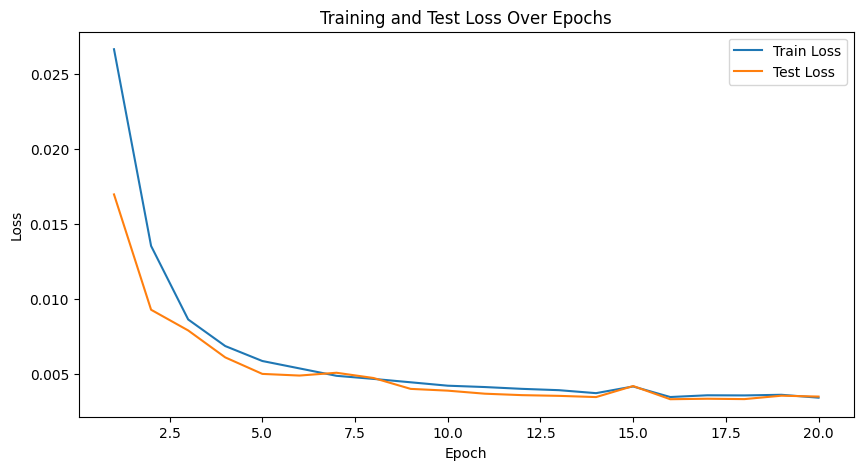

In [13]:
LAE_RECON_Trainer.save_model()
# ===================== YOUR CODE HERE ======================
LAE_RECON_Trainer.plot_results()
# ===========================================================

<hr>

### <h1 style="text-align: left;">Visualize Results | <span style="color: #9370DB;">LAE</span></h1>

<hr>

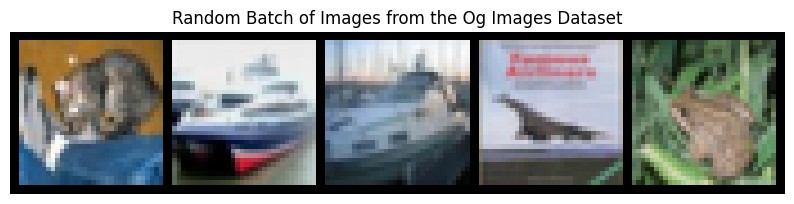

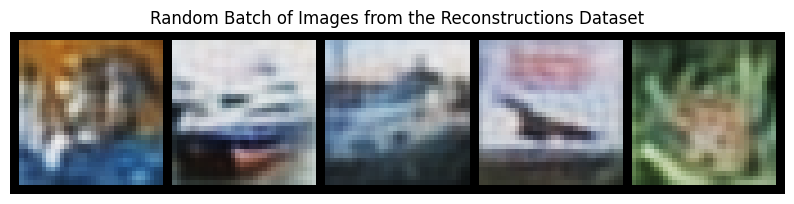

In [14]:
# ===================== YOUR CODE HERE ======================
LAE_RECON_Trainer.visualize_reconstructions(num_images=5)
# ===========================================================

Overall_Results["Task 1"] = {
    "Train Loss (Last Epoch)": 0.0034,
    "Test Loss (Last Epoch)": 0.0035,
    "Train Loss (Minimum)": 0.0034,
    "Test Loss (Minimum)": 0.0033,
}

<hr>

### <h1 style="text-align: left;">Task 1 | <span style="color: #9370DB;">End</span></h1>

<hr>

<hr>

## <h1 style="text-align: left;"><b>Task 2: Convolutional Autoencoder Reconstruction | <span style="color: #9370DB;">CIFAR-10</span></b></h1>

<hr>


### <h2>1. In a Convolutional Autoencoder (CAE):</h2>

<ul>
    <li>The <b>encoder</b> primarily uses <code>Conv2d</code> and <code>MaxPool2d</code> layers for feature extraction and dimensionality reduction.</li>
    <li>The <b>decoder</b> utilizes <code>ConvTranspose2d</code> to upsample and reconstruct the original image.</li>
</ul>

<hr>

<h2>2. Convolutional Layers in a Convolutional Autoencoder</h2>

<table border="1" cellpadding="10" cellspacing="0" width="100%">
    <tr style="background-color:rgb(60, 60, 60);">
        <th style="text-align: left;">Layer</th>
        <th style="text-align: left;">Function</th>
    </tr>
    <tr>
        <td><b>Conv2d</b></td>
        <td>Extracts spatial features from the input image by applying filters.</td>
    </tr>
    <tr>
        <td><b>MaxPool2d</b></td>
        <td>Downsamples feature maps to reduce spatial dimensions while preserving key information.</td>
    </tr>
    <tr>
        <td><b>ConvTranspose2d</b></td>
        <td>Upsamples the compressed feature maps to reconstruct the original image.</td>
    </tr>
</table>

<p>You can read the PyTorch documentation aswell for more information!</p>

<hr>

<h2>3. Understanding Conv2d and ConvTranspose2d</h2>

<h3>Conv2d</h3>
<p>A <b>2D Convolutional Layer</b> applies filters (kernels) to the input image to extract spatial patterns such as edges and textures.</p>
<p><b>Syntax:</b></p>
<pre style="background-color:rgb(60, 60, 60); padding: 10px; border-radius: 5px;">
nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding)
</pre>

<ul>
    <li><b>in_channels:</b> Number of input channels (e.g., 3 for RGB images).</li>
    <li><b>out_channels:</b> Number of filters applied to extract features.</li>
    <li><b>kernel_size:</b> Size of the filter (e.g., 3×3).</li>
    <li><b>stride:</b> Step size for moving the filter across the image.</li>
    <li><b>padding:</b> Adds zero-padding to maintain spatial dimensions.</li>
</ul>

<h3>ConvTranspose2d</h3>
<p>The <b>ConvTranspose2d</b> layer performs the reverse operation of <b>Conv2d</b>, increasing the spatial dimensions of the feature maps.</p>
<p><b>Syntax:</b></p>
<pre style="background-color:rgb(60, 60, 60); padding: 10px; border-radius: 5px;">
nn.ConvTranspose2d(in_channels, out_channels, kernel_size, stride, padding)
</pre>

<ul>
    <li><b>in_channels:</b> Number of channels from the latent space.</li>
    <li><b>out_channels:</b> Number of filters used to reconstruct the image.</li>
    <li><b>kernel_size:</b> Size of the upsampling filter.</li>
    <li><b>stride:</b> Determines how much the feature maps expand.</li>
    <li><b>padding:</b> Adjusts spatial dimensions for accurate reconstruction.</li>
</ul>

<hr>

<hr>

### <h1 style="text-align: left;">Class | <span style="color: #9370DB;">Convolutional AutoEncoder</span></h1>

<hr>

In [15]:
class ConvolutionalAutoencoderRecon(nn.Module):
    def __init__(self):
        super(ConvolutionalAutoencoderRecon, self).__init__()
        # ===================== YOUR CODE HERE =====================
        
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=2, padding=1),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(in_channels=32, out_channels=16, kernel_size=3,stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(in_channels=16, out_channels=3, kernel_size=3,stride=2, padding=1, output_padding=1),
            nn.Sigmoid() 
        )
        
        # ===========================================================
        
    def forward(self, x):
        # ===================== YOUR CODE HERE =====================
    
        x = self.encoder(x)
        x = self.decoder(x)
        
        # ===========================================================
        return x

<hr>

### <h1 style="text-align: left;">Class | <span style="color: #9370DB;">CAERecon</span></h1>

<hr>

### <p><strong>Overview:</strong><br>
The <code>CAERecon</code> is a class designed to facilitate the training, evaluation, and visualization of a <strong>Convolutional Autoencoder (CAE)</strong> model. It handles the training loop, computes losses, performs model evaluations after each epoch, and enables visualization of reconstructions to monitor model progress. The class also provides methods to save and load the model at any point.</p>

---

<h3>Constructor (<code>__init__</code>):</h3>
<p>The constructor initializes key components for training, evaluation, and visualization:</p>
<ul>
  <li><code>model (nn.Module)</code>: The Autoencoder model to be trained.</li>
  <li><code>train_loader (DataLoader)</code>: The training dataset loader.</li>
  <li><code>test_loader (DataLoader)</code>: The test dataset loader.</li>
  <li><code>lr (float)</code>: Learning rate for the optimizer (default is <code>0.001</code>).</li>
  <li><code>num_epochs (int)</code>: Number of epochs for training (default is <code>20</code>).</li>
  <li><code>device (str or None)</code>: Specifies the device for computation (e.g., 'cuda', 'mps', 'cpu'). It auto-detects if set to <code>None</code>.</li>
  <li><code>imshow_func (function or None)</code>: An optional function for visualizing images (reconstructed outputs from the model). This allows for custom image visualization logic, if needed.</li>
</ul>
<p>The constructor sets up the model, loss function (<code>MSELoss</code>), optimizer (<code>Adam</code>), and prepares lists for storing training and test losses. It also prints a summary of the model.</p>

---

<h3>Methods:</h3>

<h4>1. Training (<code>train</code>)</h4>
<p><strong>Purpose:</strong> Trains the autoencoder model over a specified number of epochs.</p>
<p><strong>Workflow:</strong> Iterates over training data, performing a forward pass, calculating loss, and updating model weights using backpropagation. After every epoch, the method prints the training loss and calls the <code>evaluate</code> method to assess the model on the test dataset.</p>
<p><strong>Outputs:</strong> Prints the average training loss at the end of each epoch.</p>

<h4>2. Evaluation (<code>evaluate</code>)</h4>
<p><strong>Purpose:</strong> Evaluates the trained model's performance on the test dataset after each epoch.</p>
<p><strong>Workflow:</strong> The model is set to evaluation mode (<code>eval</code>), and predictions are made on the test set. The <strong>test loss</strong> is computed by comparing the model's outputs with the ground truth.</p>
<p><strong>Outputs:</strong> Prints the test loss for the current epoch.</p>

<h4>3. Model Saving (<code>save_model</code>)</h4>
<p><strong>Purpose:</strong> Saves the trained model to a file.</p>
<p><strong>Path:</strong> The model is saved to the provided path (default is <code>/models/cae_model.pth</code>).</p>
<p><strong>Outputs:</strong> Prints a message confirming the model has been saved to the specified path.</p>

<h4>4. Model Loading (<code>load_model</code>)</h4>
<p><strong>Purpose:</strong> Loads a pre-trained model from a file.</p>
<p><strong>Path:</strong> Loads the model from the specified path (default is <code>/models/cae_model.pth</code>).</p>
<p><strong>Outputs:</strong> Prints a message confirming the model has been loaded from the specified path.</p>

<h4>5. Plotting Results (<code>plot_results</code>)</h4>
<p><strong>Purpose:</strong> Plots the training and test losses over the course of training.</p>
<p><strong>Workflow:</strong> After training, this method visualizes the losses for both training and test sets over all epochs.</p>
<p><strong>Outputs:</strong> Displays a plot with two lines: one for <strong>training loss</strong> and one for <strong>test loss</strong>, enabling a comparison of performance.</p>

<h4>6. Visualization of Reconstructions (<code>visualize_reconstructions</code>)</h4>
<p><strong>Purpose:</strong> Visualizes the <strong>original images</strong> alongside their <strong>reconstructed outputs</strong> from the trained model.</p>
<p><strong>Workflow:</strong> The model is set to evaluation mode (<code>eval</code>). A batch of test images is passed through the model to obtain reconstructions. A few images (specified by <code>num_images</code>) are displayed, where the first image in each pair is the ground truth and the second is the reconstruction.</p>
<p><strong>Outputs:</strong> Displays side-by-side visualizations of original and reconstructed images for comparison.</p>

---

<h3>Example Usage:</h3>

```python
# Instantiate the CAERecon class
trainer = CAERecon(model, train_loader, test_loader, lr=0.001, num_epochs=20, device='cuda')

# Start training
trainer.train()

# After training, plot the training and test losses
trainer.plot_results()

# Visualize the reconstructions from the test set
trainer.visualize_reconstructions(num_images=5)
```

---

<h3>Summary:</h3>
<p>The <code>CAERecon</code> class provides an end-to-end solution for training a <strong>Convolutional Autoencoder (CAE)</strong> model. It includes methods for:</p>
<ul>
  <li>Training and loss calculation</li>
  <li>Periodic evaluation and printing of test losses</li>
  <li>Visualizing reconstructed images alongside ground truth</li>
  <li>Saving and loading model weights</li>
</ul>
<p>This structure helps you monitor the model's progress at each epoch, assess performance, and visualize the model's reconstructions in a streamlined manner.</p>

---

<h3>Notes:</h3>
<ul>
  <li>The class is designed to be flexible and can accept a custom image visualization function (<code>imshow_func</code>) for visualizing the model's reconstructions.</li>
  <li>Loss values are tracked during training and evaluation for both training and test sets, enabling meaningful analysis of model performance over time.</li>
</ul>

In [16]:
class CAERecon:
    def __init__(self, model, train_loader, test_loader, lr=0.001, num_epochs=20, device=None, imshow_func=None):
        """
        Initializes the Convolutional Autoencoder Trainer.

        Args:
            model (nn.Module): The Autoencoder model.
            train_loader (DataLoader): Training dataset loader.
            test_loader (DataLoader): Test dataset loader.
            lr (float): Learning rate.
            num_epochs (int): Number of training epochs.
            device (str or None): 'mps' or 'cuda' or 'cpu', auto-detect if None.
            imshow_func (function or None): Function to visualize images (reconstructions).
        """
        self.name = "Convolutional Autoencoder (Reconstruction)"
        # ===================== YOUR CODE HERE =====================
        if device is None:
            self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        else:
            self.device = torch.device(device)
        
        self.model = model.to(self.device)
        self.train_loader = train_loader
        self.test_loader = test_loader
        self.lr = lr
        self.num_epochs = num_epochs
        self.imshow_func = imshow_func

        self.criterion = nn.MSELoss()
        self.optimizer = optim.Adam(self.model.parameters(), lr=self.lr)
        self.train_losses = []
        self.test_losses = []
        # ===========================================================

    def train(self):
        """ 
        Trains the Autoencoder for a specified number of epochs.
        """
        # ===================== YOUR CODE HERE ======================
        for epoch in range(1, self.num_epochs + 1):
            self.model.train()
            running_loss = 0.0
            for inputs, _ in self.train_loader:
                inputs = inputs.to(self.device)
                self.optimizer.zero_grad()
                outputs = self.model(inputs)
                loss = self.criterion(outputs, inputs)
                loss.backward()
                self.optimizer.step()
                running_loss += loss.item() * inputs.size(0)
            
            epoch_train_loss = running_loss / len(self.train_loader.dataset)
            self.train_losses.append(epoch_train_loss)
            
            epoch_test_loss = self.evaluate(epoch, train=False)
            self.test_losses.append(epoch_test_loss)
            
            print(f"Epoch {epoch}/{self.num_epochs} | Train Loss: {epoch_train_loss:.4f} | Test Loss: {epoch_test_loss:.4f}")
        # =========================================================== 

    def evaluate(self, epoch, train=True):
        """ 
        Evaluates the Autoencoder model on the test dataset after each epoch.

        Args:
            epoch (int): Current training epoch.
        """
        # ===================== YOUR CODE HERE ======================
        self.model.eval()
        total_loss = 0.0
        loader = self.train_loader if train else self.test_loader
        with torch.no_grad():
            for inputs, _ in loader:
                inputs = inputs.to(self.device)
                outputs = self.model(inputs)
                loss = self.criterion(outputs, inputs)
                total_loss += loss.item() * inputs.size(0)
        avg_loss = total_loss / len(loader.dataset)

        return avg_loss
        # =========================================================== 

    def save_model(self, path="./models/CAE_RECON.pth"):
        """ 
        Saves the trained model to a specified file path.

        Args:
            path (str): File path to save the model.
        """
        torch.save(self.model.state_dict(), path)
        print(f"Model saved to: {path}")

    def load_model(self, path="./models/CAE_RECON.pth"):
        """ 
        Loads the trained model from a saved file.

        Args:
            path (str): File path of the saved model.
        """
        self.model.load_state_dict(torch.load(path, map_location=self.device))
        self.model.to(self.device)
        print(f"Model loaded from: {path}")

    def plot_results(self):
        """ 
        Plots the training and test loss over epochs.
        """
        # ===================== YOUR CODE HERE ======================
        plt.figure(figsize=(10, 5))
        epochs = range(1, self.num_epochs + 1)
        plt.plot(epochs, self.train_losses, label="Train Loss")
        plt.plot(epochs, self.test_losses, label="Test Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training and Test Loss Over Epochs")
        plt.legend()
        plt.show()
        # ===========================================================

    def visualize_reconstructions(self, num_images=5):
        """ 
        Visualizes the original and reconstructed images.

        Args:
            num_images (int): Number of images to display.
        """
        # ===================== YOUR CODE HERE ======================
        self.model.eval()
        dataiter = iter(self.test_loader)
        noisy_inputs, _ = next(dataiter)
        noisy_inputs = noisy_inputs.to(self.device)
        
        with torch.no_grad():
            denoised_outputs = self.model(noisy_inputs)
            
        noisy_inputs = noisy_inputs.cpu()
        denoised_outputs = denoised_outputs.cpu()
        
        orig_grid = vutils.make_grid(noisy_inputs[:num_images], nrow=num_images)
        recon_grid = vutils.make_grid(denoised_outputs[:num_images], nrow=num_images)
        
        imshow(orig_grid, "Original Images")
        imshow(recon_grid, "Reconstructions")
        # ===========================================================
        
    def create_dataset(self):
        """ 
        Creates a dataset of reconstructed images for further analysis or classification.
        
        Returns:
            DataLoader: A DataLoader containing reconstructed images and labels.
        """
        # ===================== YOUR CODE HERE ======================
        self.model.eval()
        recon_images = []
        labels = []
        with torch.no_grad():
            for inputs, lbls in self.test_loader:
                inputs = inputs.to(self.device)
                outputs = self.model(inputs)
                recon_images.append(outputs.cpu())
                labels.append(lbls)
        recon_images = torch.cat(recon_images, dim=0)
        labels = torch.cat(labels, dim=0)
        dataset = torch.utils.data.TensorDataset(recon_images, labels)
        new_loader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=False)
        return new_loader
        # =========================================================== 

<hr>

### <h1 style="text-align: left;">Model Setup | <span style="color: #9370DB;">CAE</span></h1>

<hr>

In [17]:
CAE_RECON_Model = ConvolutionalAutoencoderRecon()
CAE_RECON_Trainer = CAERecon(CAE_RECON_Model, CIFAR_10_trainloader, CIFAR_10_testloader, lr=0.001, num_epochs=20, device='mps')

<hr>

### <h1 style="text-align: left;">Training | <span style="color: #9370DB;">CAE</span></h1>

<hr>

In [18]:
# ===================== YOUR CODE HERE ======================
CAE_RECON_Trainer.train()
# ===========================================================
CAE_RECON_Trainer.save_model()

Epoch 1/20 | Train Loss: 0.0153 | Test Loss: 0.0053
Epoch 2/20 | Train Loss: 0.0046 | Test Loss: 0.0040
Epoch 3/20 | Train Loss: 0.0035 | Test Loss: 0.0030
Epoch 4/20 | Train Loss: 0.0027 | Test Loss: 0.0025
Epoch 5/20 | Train Loss: 0.0023 | Test Loss: 0.0022
Epoch 6/20 | Train Loss: 0.0021 | Test Loss: 0.0020
Epoch 7/20 | Train Loss: 0.0019 | Test Loss: 0.0018
Epoch 8/20 | Train Loss: 0.0017 | Test Loss: 0.0017
Epoch 9/20 | Train Loss: 0.0016 | Test Loss: 0.0016
Epoch 10/20 | Train Loss: 0.0015 | Test Loss: 0.0014
Epoch 11/20 | Train Loss: 0.0014 | Test Loss: 0.0014
Epoch 12/20 | Train Loss: 0.0014 | Test Loss: 0.0013
Epoch 13/20 | Train Loss: 0.0013 | Test Loss: 0.0013
Epoch 14/20 | Train Loss: 0.0012 | Test Loss: 0.0012
Epoch 15/20 | Train Loss: 0.0012 | Test Loss: 0.0011
Epoch 16/20 | Train Loss: 0.0011 | Test Loss: 0.0011
Epoch 17/20 | Train Loss: 0.0011 | Test Loss: 0.0010
Epoch 18/20 | Train Loss: 0.0010 | Test Loss: 0.0010
Epoch 19/20 | Train Loss: 0.0010 | Test Loss: 0.0010
Ep

<hr>

### <h1 style="text-align: left;">Plot Results | <span style="color: #9370DB;">CAE</span></h1>

<hr>

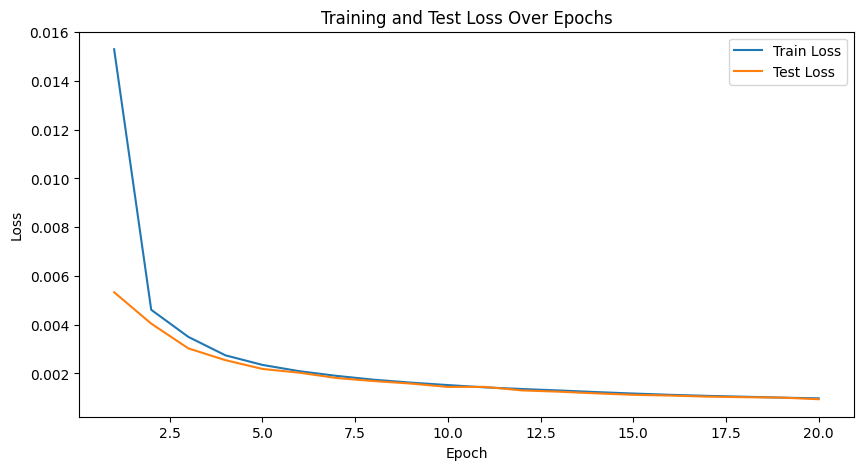

In [19]:
# ===================== YOUR CODE HERE ======================
CAE_RECON_Trainer.plot_results()
# ===========================================================

<hr>

### <h1 style="text-align: left;">Visualize Results | <span style="color: #9370DB;">CAE</span></h1>

<hr>

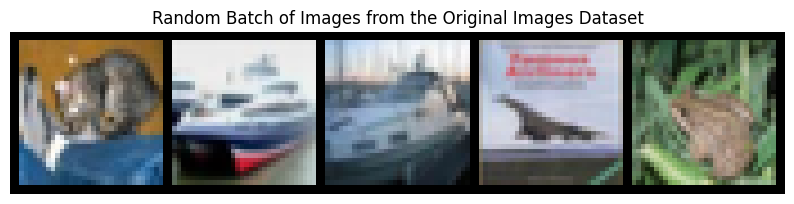

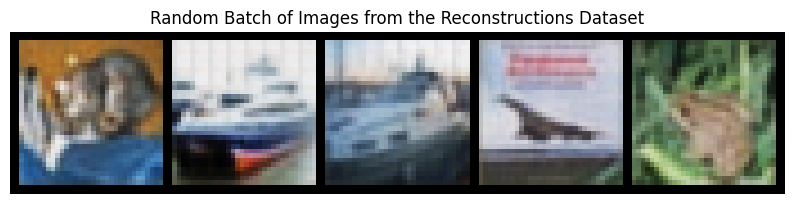

In [20]:
# ===================== YOUR CODE HERE ======================
CAE_RECON_Trainer.visualize_reconstructions()
# ===========================================================

Overall_Results["Task 2"] = {
    "Train Loss (Last Epoch)": 0.0010,
    "Test Loss (Last Epoch)": 0.0009,
    "Train Loss (Minimum)": 0.0010,
    "Test Loss (Minimum)": 0.0009,
}

<hr>

## <h1 style="text-align: left;"><b>Task 3: Linear Autoencoder Denoising | <span style="color: #9370DB;">MNIST</span></b></h1>

<hr>

<hr>

### <h1 style="text-align: left;">Class | <span style="color: #9370DB;">Linear Autoencoder</span></h1>

<hr>

In [49]:
class LinearAutoencoderDenoise(nn.Module):
    def __init__(self):
        super(LinearAutoencoderDenoise, self).__init__()
        # ===================== YOUR CODE HERE =====================
        
        input_dim = 28 * 28
        hidden_dim = 64

        self.encoder = nn.Linear(input_dim, hidden_dim)
        self.decoder = nn.Linear(hidden_dim, input_dim)
        
        # ===========================================================
        
    def forward(self, x):
        # ===================== YOUR CODE HERE =====================
    
        batch_size = x.size(0)
        x = x.view(batch_size, -1)  
        encoded = self.encoder(x)
        x = self.decoder(encoded)
        x = torch.sigmoid(x)  
        x = x.view(batch_size, 1, 28, 28)
        return x
        # ===========================================================

<hr>

### <h1 style="text-align: left;">Class | <span style="color: #9370DB;">LAEDenoise</span></h1>

<hr>

In [ ]:
class LAEDenoise:
    def __init__(self, model, train_loader, test_loader, lr=0.001, num_epochs=20, device=None, imshow_func=None):
        """
        Initializes the Linear Autoencoder Trainer for Denoising.

        Args:
            model (nn.Module): The Autoencoder model.
            train_loader (DataLoader): Training dataset loader.
            test_loader (DataLoader): Test dataset loader.
            lr (float): Learning rate.
            num_epochs (int): Number of training epochs.
            device (str or None): 'mps' or 'cuda' or 'cpu', auto-detect if None.
            imshow_func (function or None): Function to visualize images (denoised reconstructions).
        """
        self.name = "Linear Autoencoder (Denoising)"
        # ===================== YOUR CODE HERE =====================
        if device is None:
            self.device = torch.device("mps" if torch.cuda.is_available() else "cpu")
        else:
            self.device = torch.device(device)
        
        self.model = model.to(self.device)
        self.train_loader = train_loader
        self.test_loader = test_loader
        self.lr = lr
        self.num_epochs = num_epochs
        self.imshow_func = imshow_func
        
        self.criterion = nn.MSELoss()
        self.optimizer = optim.Adam(self.model.parameters(), lr=self.lr)
        self.train_losses = []
        self.test_losses = []
        # ===========================================================

    def train(self):
        """ 
        Trains the Autoencoder for a specified number of epochs.
        """
        # ===================== YOUR CODE HERE ======================
        for epoch in range(1, self.num_epochs + 1):
            self.model.train()
            running_loss = 0.0
            for noisy_inputs, _ in self.train_loader:
                noisy_inputs = noisy_inputs.to(self.device)
                targets = noisy_inputs  
                
                self.optimizer.zero_grad()
                outputs = self.model(noisy_inputs)
                batch_size = noisy_inputs.size(0)
                outputs_flat = outputs.view(batch_size, -1)
                targets_flat = targets.view(batch_size, -1)
                loss = self.criterion(outputs_flat, targets_flat)
                loss.backward()
                self.optimizer.step()
                running_loss += loss.item() * batch_size
            
            epoch_train_loss = running_loss / len(self.train_loader.dataset)
            self.train_losses.append(epoch_train_loss)
            
            epoch_test_loss = self.evaluate(epoch, train=False)
            self.test_losses.append(epoch_test_loss)
            
            print(f"Epoch {epoch}/{self.num_epochs} | Train Loss: {epoch_train_loss:.4f} | Test Loss: {epoch_test_loss:.4f}")

        # =========================================================== 

    def evaluate(self, epoch, train=True):
        """ 
        Evaluates the Autoencoder model on the test dataset after each epoch.

        Args:
            epoch (int): Current training epoch.
        """
        # ===================== YOUR CODE HERE ======================
        self.model.eval()
        total_loss = 0.0
        loader = self.train_loader if train else self.test_loader
        with torch.no_grad():
            for noisy_inputs, _ in loader:
                noisy_inputs = noisy_inputs.to(self.device)
                targets = noisy_inputs  
                outputs = self.model(noisy_inputs)
                batch_size = noisy_inputs.size(0)
                outputs_flat = outputs.view(batch_size, -1)
                targets_flat = targets.view(batch_size, -1)
                loss = self.criterion(outputs_flat, targets_flat)
                total_loss += loss.item() * batch_size
        avg_loss = total_loss / len(loader.dataset)
        return avg_loss
        # =========================================================== 

    def save_model(self, path="./models/LAE_DENOISE.pth"):
        """ 
        Saves the trained model to a specified file path.

        Args:
            path (str): File path to save the model.
        """
        torch.save(self.model.state_dict(), path)
        print(f"Model saved to: {path}")

    def load_model(self, path="./models/LAE_DENOISE.pth"):
        """ 
        Loads the trained model from a saved file.

        Args:
            path (str): File path of the saved model.
        """
        self.model.load_state_dict(torch.load(path, map_location=self.device))
        self.model.to(self.device)
        print(f"Model loaded from: {path}")

    def plot_results(self):
        """ 
        Plots the training and test loss over epochs.
        """
        # ===================== YOUR CODE HERE =====================
        plt.figure(figsize=(10, 5))
        epochs = range(1, self.num_epochs + 1)
        plt.plot(epochs, self.train_losses, label="Train Loss")
        plt.plot(epochs, self.test_losses, label="Test Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training and Test Loss Over Epochs")
        plt.legend()
        plt.show()
        # ===========================================================

    def visualize_denoising(self, num_images=5):
        """ 
        Visualizes the original and denoised images.

        Args:
            num_images (int): Number of images to display.
        """
        # ===================== YOUR CODE HERE =====================
        self.model.eval()
        dataiter = iter(self.test_loader)
        noisy_inputs, _ = next(dataiter)
        noisy_inputs = noisy_inputs.to(self.device)
        
        with torch.no_grad():
            denoised_outputs = self.model(noisy_inputs)
            
        noisy_inputs = noisy_inputs.cpu()
        denoised_outputs = denoised_outputs.cpu()
        
        orig_grid = vutils.make_grid(noisy_inputs[:num_images], nrow=num_images)
        recon_grid = vutils.make_grid(denoised_outputs[:num_images], nrow=num_images)
        
        imshow(orig_grid, "Noisy Images")
        imshow(recon_grid, "Denoised Reconstructions")
        # ===========================================================
        
    def create_dataset(self):
        """ 
        Creates a dataset of reconstructed images for further analysis or classification.
        
        Returns:
            DataLoader: A DataLoader containing reconstructed images and labels.
        """
        # ===================== YOUR CODE HERE ======================
        self.model.eval()
        denoised_images = []
        labels = []
        with torch.no_grad():
            for noisy_inputs, lbls in self.test_loader:
                noisy_inputs = noisy_inputs.to(self.device)
                outputs = self.model(noisy_inputs)
                denoised_images.append(outputs.cpu())
                labels.append(lbls)
        denoised_images = torch.cat(denoised_images, dim=0)
        labels = torch.cat(labels, dim=0)
        dataset = torch.utils.data.TensorDataset(denoised_images, labels)
        new_loader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=False)
        return new_loader
        # =========================================================== 

<hr>

### <h1 style="text-align: left;">Model Setup | <span style="color: #9370DB;">LAE</span></h1>

<hr>

In [52]:
LAE_DENOISE_Model = LinearAutoencoderDenoise()
LAE_DENOISE_Trainer = LAEDenoise(LAE_DENOISE_Model, MNIST_trainloader_noisy, MNIST_testloader_noisy, lr=0.001, num_epochs=20, device='mps')

<hr>

### <h1 style="text-align: left;">Training | <span style="color: #9370DB;">LAE</span></h1>

<hr>

In [65]:
# ===================== YOUR CODE HERE ======================
LAE_DENOISE_Trainer.train()
# ===========================================================

Epoch 1/20 | Train Loss: 0.2923 | Test Loss: 0.2659
Epoch 2/20 | Train Loss: 0.2595 | Test Loss: 0.2543
Epoch 3/20 | Train Loss: 0.2520 | Test Loss: 0.2496
Epoch 4/20 | Train Loss: 0.2487 | Test Loss: 0.2475
Epoch 5/20 | Train Loss: 0.2475 | Test Loss: 0.2469
Epoch 6/20 | Train Loss: 0.2468 | Test Loss: 0.2464
Epoch 7/20 | Train Loss: 0.2464 | Test Loss: 0.2461
Epoch 8/20 | Train Loss: 0.2461 | Test Loss: 0.2460
Epoch 9/20 | Train Loss: 0.2460 | Test Loss: 0.2457
Epoch 10/20 | Train Loss: 0.2459 | Test Loss: 0.2457
Epoch 11/20 | Train Loss: 0.2458 | Test Loss: 0.2454
Epoch 12/20 | Train Loss: 0.2457 | Test Loss: 0.2456
Epoch 13/20 | Train Loss: 0.2457 | Test Loss: 0.2453
Epoch 14/20 | Train Loss: 0.2456 | Test Loss: 0.2453
Epoch 15/20 | Train Loss: 0.2455 | Test Loss: 0.2455
Epoch 16/20 | Train Loss: 0.2454 | Test Loss: 0.2453
Epoch 17/20 | Train Loss: 0.2454 | Test Loss: 0.2453
Epoch 18/20 | Train Loss: 0.2455 | Test Loss: 0.2454
Epoch 19/20 | Train Loss: 0.2455 | Test Loss: 0.2451
Ep

<hr>

### <h1 style="text-align: left;">Plot Results | <span style="color: #9370DB;">LAE</span></h1>

<hr>

Model saved to: ./models/LAE_DENOISE.pth


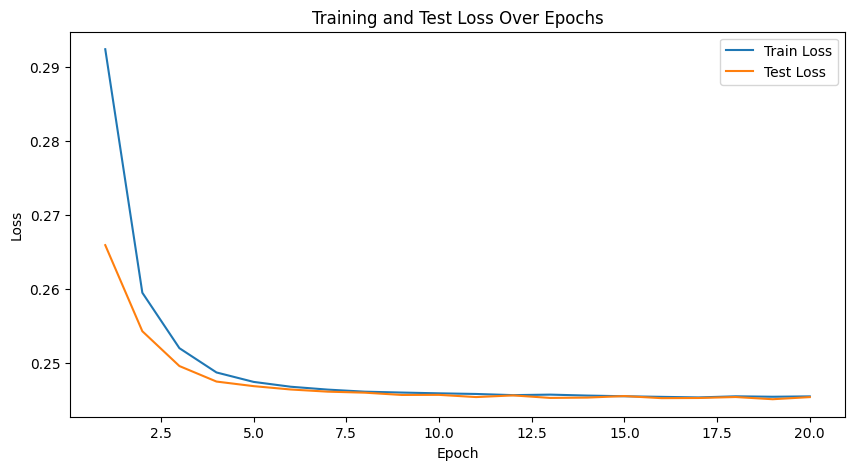

In [66]:
# ===================== YOUR CODE HERE ======================
LAE_DENOISE_Trainer.save_model()
LAE_DENOISE_Trainer.plot_results()
# ===========================================================

<hr>

### <h1 style="text-align: left;">Visualize Results | <span style="color: #9370DB;">LAE</span></h1>

<hr>

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


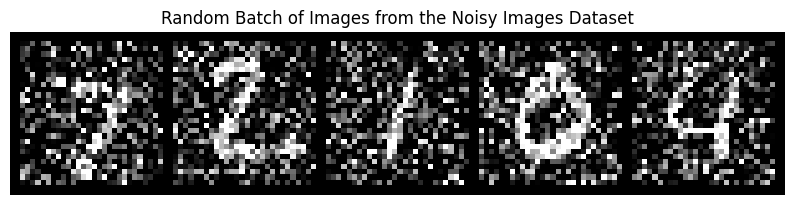

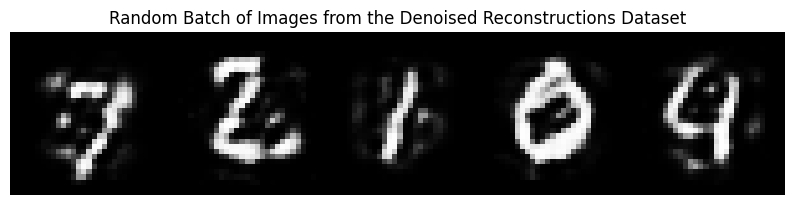

In [ ]:
# ===================== YOUR CODE HERE ======================
LAE_DENOISE_Trainer.visualize_denoising()
# ===========================================================

Overall_Results["Task 3"] = {
    "Train Loss (Last Epoch)": 0.2455,
    "Test Loss (Last Epoch)": 0.2454,
    "Train Loss (Minimum)": 0.2454,
    "Test Loss (Minimum)": 0.2451,
}

<hr>

### <h1 style="text-align: left;">Task 3 | <span style="color: #9370DB;">End</span></h1>

<hr>

<hr>

## <h1 style="text-align: left;"><b>Task 4: Convolutional Autoencoder Denoising | <span style="color: #9370DB;">MNIST</span></b></h1>

<hr>

<hr>

### <h1 style="text-align: left;">Class | <span style="color: #9370DB;">Convolutional AutoEncoder</span></h1>

<hr>

In [46]:
class ConvolutionalAutoencoderDenoise(nn.Module):
    def __init__(self):
        super(ConvolutionalAutoencoderDenoise, self).__init__()
        # ===================== YOUR CODE HERE ======================
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2, padding=1),  
            nn.BatchNorm2d(16),
            nn.ReLU(True),
            nn.Conv2d(16, 32, 3, stride=2, padding=1),  
            nn.BatchNorm2d(32),
            nn.ReLU(True)
        )

        self.fc_enc = nn.Linear(32*7*7, 256)
        self.fc_dec = nn.Linear(256, 32*7*7)
        
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(in_channels=32, out_channels=16, kernel_size=3, stride=2, padding=1, output_padding=1), 
            nn.BatchNorm2d(16),
            nn.ReLU(True),
            nn.ConvTranspose2d(in_channels=16, out_channels=1, kernel_size=3, stride=2, padding=1, output_padding=1),    
            nn.Sigmoid()
        )
        # =========================================================== 
        
    def forward(self, x):
        # ===================== YOUR CODE HERE ======================
        x = self.encoder(x)
        x = x.view(x.size(0), -1)
        x = self.fc_enc(x)
        x = self.fc_dec(x)
        x = x.view(x.size(0), 32, 7, 7)
        x = self.decoder(x)
        return x
        # ===========================================================

<hr>

### <h1 style="text-align: left;">Class | <span style="color: #9370DB;">CAEDenoise</span></h1>

<hr>

In [47]:
class CAEDenoise:
    def __init__(self, model, train_loader, test_loader, lr=0.001, num_epochs=20, device=None, imshow_func=None):
        """
        Initializes the Convolutional Autoencoder Trainer for Denoising.

        Args:
            model (nn.Module): The Autoencoder model.
            train_loader (DataLoader): Training dataset loader.
            test_loader (DataLoader): Test dataset loader.
            lr (float): Learning rate.
            num_epochs (int): Number of training epochs.
            device (str or None): 'mps' or 'cuda' or 'cpu', auto-detect if None.
            imshow_func (function or None): Function to visualize images (denoised reconstructions).
        """
        self.name = "Convolutional Autoencoder (Denoising)"
        # ===================== YOUR CODE HERE ======================
        if device is None:
            self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        else:
            self.device = torch.device(device)
        self.model = model.to(self.device)
        self.train_loader = train_loader
        self.test_loader = test_loader
        self.lr = lr
        self.num_epochs = num_epochs
        self.imshow_func = imshow_func
        
        self.criterion = nn.MSELoss()
        self.optimizer = optim.Adam(self.model.parameters(), lr=self.lr)
        self.train_losses = []
        self.test_losses = []
        # =========================================================== 

    def train(self):
        """ 
        Trains the Autoencoder for a specified number of epochs.
        """
        # ===================== YOUR CODE HERE ======================
        for epoch in range(1, self.num_epochs + 1):
            self.model.train()
            running_loss = 0.0
            for noisy_inputs, _ in self.train_loader:
                noisy_inputs = noisy_inputs.to(self.device)
                targets = noisy_inputs  
                
                self.optimizer.zero_grad()
                outputs = self.model(noisy_inputs)
                batch_size = noisy_inputs.size(0)
                outputs_flat = outputs.view(batch_size, -1)
                targets_flat = targets.view(batch_size, -1)
                loss = self.criterion(outputs_flat, targets_flat)
                loss.backward()
                self.optimizer.step()
                running_loss += loss.item() * batch_size
            
            epoch_train_loss = running_loss / len(self.train_loader.dataset)
            self.train_losses.append(epoch_train_loss)
            
            epoch_test_loss = self.evaluate(epoch, train=False)
            self.test_losses.append(epoch_test_loss)
            
            print(f"Epoch {epoch}/{self.num_epochs} | Train Loss: {epoch_train_loss:.4f} | Test Loss: {epoch_test_loss:.4f}")
        # =========================================================== 

    def evaluate(self, epoch, train=True):
        """ 
        Evaluates the Autoencoder model on the test dataset after each epoch.

        Args:
            epoch (int): Current training epoch.
        """
        # ===================== YOUR CODE HERE ======================
        self.model.eval()
        total_loss = 0.0
        loader = self.train_loader if train else self.test_loader
        with torch.no_grad():
            for noisy_inputs, _ in loader:
                noisy_inputs = noisy_inputs.to(self.device)
                targets = noisy_inputs  
                outputs = self.model(noisy_inputs)
                batch_size = noisy_inputs.size(0)
                outputs_flat = outputs.view(batch_size, -1)
                targets_flat = targets.view(batch_size, -1)
                loss = self.criterion(outputs_flat, targets_flat)
                total_loss += loss.item() * batch_size
        avg_loss = total_loss / len(loader.dataset)
        return avg_loss
            # =========================================================== 

    def save_model(self, path="./models/CAE_DENOISE.pth"):
        """ 
        Saves the trained model to a specified file path.

        Args:
            path (str): File path to save the model.
        """
        torch.save(self.model.state_dict(), path)
        print(f"Model saved to: {path}")

    def load_model(self, path="./models/CAE_DENOISE.pth"):
        """ 
        Loads the trained model from a saved file.

        Args:
            path (str): File path of the saved model.
        """
        self.model.load_state_dict(torch.load(path, map_location=self.device))
        self.model.to(self.device)
        print(f"Model loaded from: {path}")

    def plot_results(self):
        """ 
        Plots the training and test loss over epochs.
        """
        # ===================== YOUR CODE HERE =====================
        plt.figure(figsize=(10, 5))
        epochs = range(1, self.num_epochs + 1)
        plt.plot(epochs, self.train_losses, label="Train Loss")
        plt.plot(epochs, self.test_losses, label="Test Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training and Test Loss Over Epochs")
        plt.legend()
        plt.show()
        # ===========================================================

    def visualize_denoising(self, num_images=5):
        """ 
        Visualizes the original and denoised images.

        Args:
            num_images (int): Number of images to display.
        """
        # ===================== YOUR CODE HERE =====================
        self.model.eval()
        dataiter = iter(self.test_loader)
        noisy_inputs, clean_targets = next(dataiter)
        noisy_inputs = noisy_inputs.to(self.device)
        with torch.no_grad():
            denoised_outputs = self.model(noisy_inputs)
        noisy_inputs = noisy_inputs.cpu()
        denoised_outputs = denoised_outputs.cpu()
        
        noisy_grid = vutils.make_grid(noisy_inputs[:num_images], nrow=num_images)
        denoised_grid = vutils.make_grid(denoised_outputs[:num_images], nrow=num_images)
    
        self.imshow_func(noisy_grid, "Noisy Images")
        self.imshow_func(denoised_grid, "Denoised Reconstructions")
        # ===========================================================
        
    def create_dataset(self):
        """ 
        Creates a dataset of reconstructed images for further analysis or classification.
        
        Returns:
            DataLoader: A DataLoader containing reconstructed images and labels.
        """
        # ===================== YOUR CODE HERE ======================
        self.model.eval()
        recon_images = []
        labels = []
        with torch.no_grad():
            for noisy_inputs, lbls in self.test_loader:
                noisy_inputs = noisy_inputs.to(self.device)
                outputs = self.model(noisy_inputs)
                recon_images.append(outputs.cpu())
                labels.append(lbls)
        recon_images = torch.cat(recon_images, dim=0)
        labels = torch.cat(labels, dim=0)
        dataset = torch.utils.data.TensorDataset(recon_images, labels)
        new_loader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=False)
        return new_loader
        # =========================================================== 

<hr>

### <h1 style="text-align: left;">Model Setup | <span style="color: #9370DB;">CAE</span></h1>

<hr>

In [206]:
CAE_DENOISE_Model = ConvolutionalAutoencoderDenoise()
CAE_DENOISE_Trainer = CAEDenoise(CAE_DENOISE_Model, MNIST_trainloader_noisy, MNIST_testloader_noisy, lr=0.001, num_epochs=20, device='mps', imshow_func=imshow)

<hr>

### <h1 style="text-align: left;">Training | <span style="color: #9370DB;">CAE</span></h1>

<hr>

In [207]:
# ===================== YOUR CODE HERE ======================
CAE_DENOISE_Trainer.train()
# ===========================================================
CAE_DENOISE_Trainer.save_model()

Epoch 1/20 | Train Loss: 0.2680 | Test Loss: 0.2196
Epoch 2/20 | Train Loss: 0.2101 | Test Loss: 0.2053
Epoch 3/20 | Train Loss: 0.2029 | Test Loss: 0.2008
Epoch 4/20 | Train Loss: 0.1994 | Test Loss: 0.1981
Epoch 5/20 | Train Loss: 0.1967 | Test Loss: 0.1956
Epoch 6/20 | Train Loss: 0.1948 | Test Loss: 0.1938
Epoch 7/20 | Train Loss: 0.1932 | Test Loss: 0.1923
Epoch 8/20 | Train Loss: 0.1919 | Test Loss: 0.1913
Epoch 9/20 | Train Loss: 0.1909 | Test Loss: 0.1906
Epoch 10/20 | Train Loss: 0.1901 | Test Loss: 0.1897
Epoch 11/20 | Train Loss: 0.1893 | Test Loss: 0.1890
Epoch 12/20 | Train Loss: 0.1886 | Test Loss: 0.1884
Epoch 13/20 | Train Loss: 0.1881 | Test Loss: 0.1882
Epoch 14/20 | Train Loss: 0.1876 | Test Loss: 0.1874
Epoch 15/20 | Train Loss: 0.1873 | Test Loss: 0.1874
Epoch 16/20 | Train Loss: 0.1869 | Test Loss: 0.1867
Epoch 17/20 | Train Loss: 0.1864 | Test Loss: 0.1866
Epoch 18/20 | Train Loss: 0.1861 | Test Loss: 0.1858
Epoch 19/20 | Train Loss: 0.1858 | Test Loss: 0.1855
Ep

<hr>

### <h1 style="text-align: left;">Plot Results | <span style="color: #9370DB;">CAE</span></h1>

<hr>

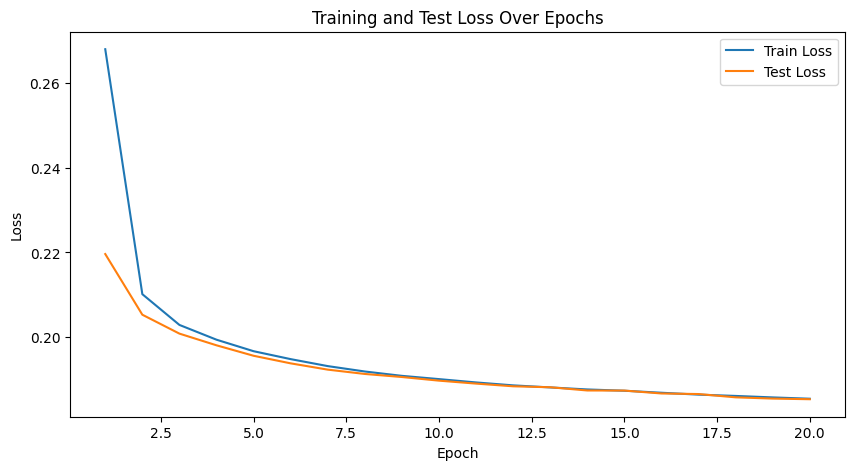

In [208]:
# ===================== YOUR CODE HERE ======================
CAE_DENOISE_Trainer.plot_results()        
# ===========================================================


<hr>

### <h1 style="text-align: left;">Visualize Results | <span style="color: #9370DB;">CAE</span></h1>

<hr>

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


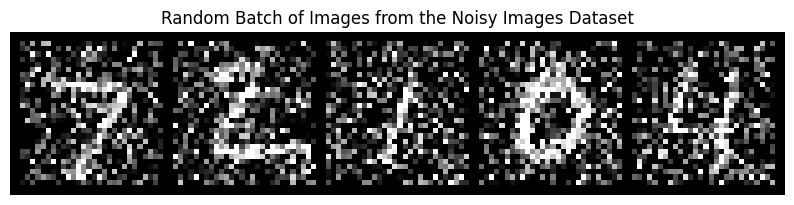

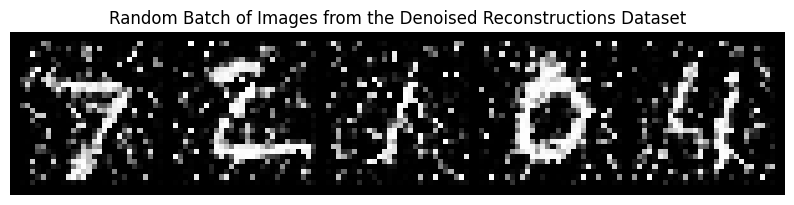

In [ ]:
# ===================== YOUR CODE HERE ======================
CAE_DENOISE_Trainer.visualize_denoising()        
# ===========================================================


Overall_Results["Task 4"] = {
    "Train Loss (Last Epoch)": 0.1855,
    "Test Loss (Last Epoch)": 0.1853,
    "Train Loss (Minimum)": 0.1855,
    "Test Loss (Minimum)": 0.1853,
}

<hr>

### <h1 style="text-align: left;">Task 4 | <span style="color: #9370DB;">End</span></h1>

<hr>

<hr>

## <h1 style="text-align: left;"><b>Task 5: Image Classification (Reconstruction) | <span style="color: #9370DB;">CIFAR</span></b></h1>

<hr>

### <h2>1. CIFAR-10 Data Preparation:</h2>

<ul>
    <li><b>Original Data:</b> Use the original CIFAR-10 dataset.</li>
    <li><b>LAE Recon Data:</b> Feed the CIFAR-10 images through the LAE model to obtain the reconstructed images.</li>
    <li><b>CAE Recon Data:</b> Feed the CIFAR-10 images through the CAE model to obtain the reconstructed images.</li>
</ul>

<hr>

<h2>2. Classification Model:</h2>

<p>The task requires training a classifier on the following datasets:</p>
<ul>
    <li><b>Original CIFAR-10:</b> Directly train a classifier on the original CIFAR-10 dataset.</li>
</ul>

<hr>

<h2>3. Evaluation Metrics:</h2>

<p>The following metrics should be used to evaluate and compare the performance of the classifier on each test dataset:</p>

<ul>
    <li><b>Accuracy:</b> Percentage of correct classifications.</li>
    <li><b>Precision:</b> The proportion of positive identifications that were actually correct.</li>
    <li><b>Recall:</b> The proportion of actual positives that were correctly identified.</li>
    <li><b>F1-Score:</b> The harmonic mean of precision and recall, providing a balance between them.</li>
</ul>

<hr>

<h2>4. Comparison:</h2>

<p>For comparison:</p>

<ul>
    <li><b>Accuracy Comparison:</b> Compare the classification accuracy for the original data, LAE recon, and CAE recon.</li>
    <li><b>Confusion Matrices:</b> Plot confusion matrices for each classifier to visualize how the model performs across the different classes.</li>
</ul>

<hr>

<h2>5. Analysis:</h2>

<ul>
    <li><b>Feature Retention:</b> Analyze how well the LAE and CAE models preserve features of the original data during reconstruction.</li>
    <li><b>Impact of Reconstruction:</b> Determine the impact of reconstruction on classification accuracy and model performance.</li>
    <li><b>Best Reconstruction Model:</b> Conclude which reconstruction model (LAE or CAE) preserves the original data's classification features better.</li>
</ul>

<hr>

<h2>6. Visualization:</h2>

<ul>
    <li><b>Plot Metrics:</b> Plot the evaluation metrics (accuracy, precision, recall, F1-score) for each dataset to visualize performance differences.</li>
</ul>

Model loaded from: ./models/LAE_RECON.pth
Model loaded from: ./models/CAE_RECON.pth
Inputs shape: torch.Size([64, 3, 32, 32])
Labels: tensor([3, 8, 8, 0, 6, 6, 1, 6, 3, 1, 0, 9, 5, 7, 9, 8, 5, 7, 8, 6, 7, 0, 4, 9,
        5, 2, 4, 0, 9, 6, 6, 5, 4, 5, 9, 2, 4, 1, 9, 5, 4, 6, 5, 6, 0, 9, 3, 9,
        7, 6, 9, 8, 0, 3, 8, 8, 7, 7, 4, 6, 7, 3, 6, 3])


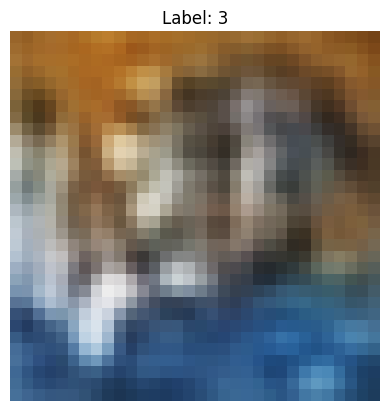

In [24]:
from torch.utils.data import TensorDataset, DataLoader

def create_reconstructed_dataloader(model, original_dataloader, device, batch_size=64):
    model.eval()
    reconstructed_images = []
    labels = []
    
    with torch.no_grad():
        for images, lbls in original_dataloader:
            images = images.to(device)
            outputs = model(images)
            reconstructed_images.append(outputs.cpu())
            labels.append(lbls)
            
    reconstructed_images = torch.cat(reconstructed_images, dim=0)
    labels = torch.cat(labels, dim=0)
    
    dataset = TensorDataset(reconstructed_images, labels)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    return dataloader


LAE_RECON_Trainer.load_model() 
CAE_RECON_Trainer.load_model()

device = torch.device("mps")
LAE_RECON_Model = LAE_RECON_Model.to(device)
CAE_RECON_Model = CAE_RECON_Model.to(device)
# ================== Create Datasets ==================
LAERecon_dataloader = create_reconstructed_dataloader(LAE_RECON_Model, CIFAR_10_testloader, torch.device("mps"))
CAERecon_dataloader = create_reconstructed_dataloader(CAE_RECON_Model, CIFAR_10_testloader, torch.device("mps"))

data_iter = iter(LAERecon_dataloader)

inputs, labels = next(data_iter)

print("Inputs shape:", inputs.shape)
print("Labels:", labels)

data_iter = iter(LAERecon_dataloader)
images, labels = next(data_iter)

img = images[0]

if img.shape[0] == 1:
    plt.imshow(img.squeeze().cpu().numpy(), cmap='gray')
else:
    plt.imshow(img.cpu().permute(1, 2, 0).numpy())
    
plt.title(f"Label: {labels[0]}")
plt.axis("off")
plt.show()


<hr>

### <h1 style="text-align: left;"> Class | <span style="color: #9370DB;">Convolutional Neural Network Recon</span></h1>

<hr>

In [70]:
class CNNRecon(nn.Module):
    def __init__(self):
        super(CNNRecon, self).__init__()
        # ===================== YOUR CODE HERE ======================
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1),  
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1), 
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)   
        )

        self.decoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, 10)
        )
        # =========================================================== 
        
    def forward(self, x):
        # ===================== YOUR CODE HERE ======================
        encoded = self.encoder(x)
        reconstructed = self.decoder(encoded)
        return reconstructed
        # =========================================================== 

<hr>

### <h1 style="text-align: left;"> Class | <span style="color: #9370DB;">CNN Classifier Recon</span></h1>

<hr>

In [71]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

class CNNClassifierRecon:
    def __init__(self, model, train_loader, test_loader, LAERecon_loader, CAERecon_loader, lr=0.001, num_epochs=20, device=None):
        """
        Initializes the CNN classifier for original and reconstructed datasets.

        Args:
            model (nn.Module): The CNN model.
            train_loader (DataLoader): Training dataset loader.
            test_loader (DataLoader): Test dataset loader.
            LAERecon_loader (DataLoader): DataLoader for LAE reconstructed images.
            CAERecon_loader (DataLoader): DataLoader for CAE reconstructed images.
            lr (float): Learning rate.
            num_epochs (int): Number of training epochs.
            device (str or None): 'cuda' or 'cpu', auto-detect if None.
        """
        self.name = "CNN Classifier Reconstruction"
        # ===================== YOUR CODE HERE ======================
        if device is None:
            self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        else:
            self.device = torch.device(device)
            
        self.model = model.to(self.device)
        self.train_loader = train_loader
        self.test_loader = test_loader
        self.LAERecon_loader = LAERecon_loader
        self.CAERecon_loader = CAERecon_loader
        self.lr = lr
        self.num_epochs = num_epochs
        
        self.criterion = nn.CrossEntropyLoss()
        self.optimizer = optim.Adam(self.model.parameters(), lr=self.lr)
        # =========================================================== 
    
    def train(self):
        """
        Trains the CNN classifier for a specified number of epochs.
        """
        # ===================== YOUR CODE HERE ======================
        self.model.train()
        train_loss_list = []
        train_accuracy_list = []
        test_loss_list = []
        test_accuracy_list = []

        for epoch in range(1, self.num_epochs + 1):
            running_loss = 0.0
            all_train_preds = []
            all_train_labels = []
            for images, labels in self.train_loader:
                images = images.to(self.device)
                labels = labels.to(self.device)
                self.optimizer.zero_grad()
                outputs = self.model(images)
                loss = self.criterion(outputs, labels)
                loss.backward()
                self.optimizer.step()
                running_loss += loss.item() * images.size(0)
                preds = torch.argmax(outputs, dim=1)
                all_train_preds.extend(preds.cpu().numpy())
                all_train_labels.extend(labels.cpu().numpy())
            epoch_train_loss = running_loss / len(self.train_loader.dataset)
            train_accuracy = accuracy_score(all_train_labels, all_train_preds)
            train_loss_list.append(epoch_train_loss)
            train_accuracy_list.append(train_accuracy)
            
            test_metrics = self.evaluate(self.test_loader, print_results=False)
            test_loss = test_metrics["loss"]
            test_accuracy = test_metrics["accuracy"]
            test_loss_list.append(test_loss)
            test_accuracy_list.append(test_accuracy)
            
            print(f"Epoch {epoch}/{self.num_epochs} | Train Loss: {epoch_train_loss:.4f} | "f"Train Accuracy: {train_accuracy:.4f} | Test Loss: {test_loss:.4f} | "f"Test Accuracy: {test_accuracy:.4f}")
        # =========================================================== 

    def evaluate(self, dataloader, print_results=True, epoch=None):
        """
        Evaluates the CNN model on a given dataset.

        Args:
            dataloader (DataLoader): The dataset loader to evaluate on.
            print_results (bool): Whether to print evaluation metrics.
            epoch (int or None): Current epoch number if evaluating during training.

        Returns:
            dict: Contains loss, accuracy, precision, recall, f1-score, and confusion matrix.
        """
        # ===================== YOUR CODE HERE ======================
        self.model.eval()
        total_loss = 0.0
        all_preds = []
        all_labels = []
        
        with torch.no_grad():
            for images, labels in dataloader:
                images = images.to(self.device)
                labels = labels.to(self.device)
                outputs = self.model(images)
                loss = self.criterion(outputs, labels)
                total_loss += loss.item() * images.size(0)
                preds = torch.argmax(outputs, dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        
        avg_loss = total_loss / len(dataloader.dataset)
        accuracy = accuracy_score(all_labels, all_preds)
        precision = precision_score(all_labels, all_preds, average='macro')
        recall = recall_score(all_labels, all_preds, average='macro')
        f1 = f1_score(all_labels, all_preds, average='macro')
        cm = confusion_matrix(all_labels, all_preds)
        
        metrics = {
            "loss": avg_loss,
            "accuracy": accuracy,
            "precision": precision,
            "recall": recall,
            "f1_score": f1,
            "confusion_matrix": cm
        }
        
        if print_results:
            print("Evaluation Metrics:")
            if epoch is not None:
                print(f"Epoch {epoch}:")
            print(f"Loss: {avg_loss:.4f}")
            print(f"Accuracy: {accuracy:.4f}")
            print(f"Precision: {precision:.4f}")
            print(f"Recall: {recall:.4f}")
            print(f"F1 Score: {f1:.4f}")
            print("Confusion Matrix:")
            print(cm)
        
        return metrics
        # =========================================================== 
    
    def save_model(self, path="CNN_RECON.pth"):
        """
        Saves the trained model to the specified file path.

        Args:
            path (str): File path to save the model.
        """
        torch.save(self.model.state_dict(), path)
        print(f"Model saved to {path}")
    
    def load_model(self, path="CNN_RECON.pth"):
        """
        Loads the trained model from the specified file path.

        Args:
            path (str): File path of the saved model.
        """
        self.model.load_state_dict(torch.load(path, map_location=self.device))
        self.model.to(self.device)
        print(f"Model loaded from {path}")

<hr>

### <h1 style="text-align: left;">Model Setup | <span style="color: #9370DB;">CNN Classifier Recon</span></h1>

<hr>

In [72]:
CNN_RECON_Model = CNNRecon()
CNN_CLASSIFIER_RECON_Trainer = CNNClassifierRecon(model=CNN_RECON_Model,train_loader=CIFAR_10_trainloader,test_loader=CIFAR_10_testloader,LAERecon_loader=LAERecon_dataloader,CAERecon_loader=CAERecon_dataloader,lr=0.001,num_epochs=20,device='mps')

<hr>

### <h1 style="text-align: left;">Training | <span style="color: #9370DB;">CNN Classifier Recon</span></h1>

<hr>

In [73]:
# ===================== YOUR CODE HERE ======================
CNN_CLASSIFIER_RECON_Trainer.train()
# ===========================================================

Epoch 1/20 | Train Loss: 1.5801 | Train Accuracy: 0.4328 | Test Loss: 1.2158 | Test Accuracy: 0.5733
Epoch 2/20 | Train Loss: 1.0142 | Train Accuracy: 0.6365 | Test Loss: 0.9099 | Test Accuracy: 0.6764
Epoch 3/20 | Train Loss: 0.8114 | Train Accuracy: 0.7142 | Test Loss: 0.8403 | Test Accuracy: 0.7057
Epoch 4/20 | Train Loss: 0.6781 | Train Accuracy: 0.7627 | Test Loss: 0.7716 | Test Accuracy: 0.7300
Epoch 5/20 | Train Loss: 0.5540 | Train Accuracy: 0.8049 | Test Loss: 0.7938 | Test Accuracy: 0.7294
Epoch 6/20 | Train Loss: 0.4436 | Train Accuracy: 0.8418 | Test Loss: 0.8341 | Test Accuracy: 0.7386
Epoch 7/20 | Train Loss: 0.3406 | Train Accuracy: 0.8788 | Test Loss: 0.8513 | Test Accuracy: 0.7390
Epoch 8/20 | Train Loss: 0.2508 | Train Accuracy: 0.9120 | Test Loss: 1.0238 | Test Accuracy: 0.7210
Epoch 9/20 | Train Loss: 0.1838 | Train Accuracy: 0.9362 | Test Loss: 1.1161 | Test Accuracy: 0.7279
Epoch 10/20 | Train Loss: 0.1360 | Train Accuracy: 0.9532 | Test Loss: 1.1597 | Test Accura

<hr>

### <h1 style="text-align: left;">Results | <span style="color: #9370DB;">CNN Classifier Recon</span></h1>

<hr>

In [74]:
# ===================== YOUR CODE HERE ======================
print("test set:")
original_metrics = CNN_CLASSIFIER_RECON_Trainer.evaluate(CIFAR_10_testloader, print_results=True)

print("LAE reconstructed dataset:")
lae_metrics = CNN_CLASSIFIER_RECON_Trainer.evaluate(LAERecon_dataloader, print_results=True)

print("CAE reconstructed dataset:")
cae_metrics = CNN_CLASSIFIER_RECON_Trainer.evaluate(CAERecon_dataloader, print_results=True)
# ===========================================================

CNN_CLASSIFIER_RECON_Trainer.save_model("./models/CNN_RECON.pth")

Overall_Results["Task 5"] = {
    "Train Loss (Last Epoch)": 0.0595,
    "Test Loss (Last Epoch)": 1.9120,
    "Train Accuracy (Last Epoch)": 0.9799,
    "Test Accuracy (Last Epoch)": 0.7232,
    "Train Loss (Minimum)": 0.0595,
    "Test Loss (Minimum)": 0.7716,
    "Train Accuracy (Maximum)": 0.9799,
    "Test Accuracy (Maximum)": 0.7320,
}

test set:
Evaluation Metrics:
Loss: 1.9120
Accuracy: 0.7232
Precision: 0.7234
Recall: 0.7232
F1 Score: 0.7227
Confusion Matrix:
[[777  19  52  23  28   5   9   5  44  38]
 [ 17 855   4   7   4   3   7   2  18  83]
 [ 86   9 599  62  76  58  56  29  15  10]
 [ 28  17  61 524  74 176  62  26  13  19]
 [ 22   7  67  66 687  40  56  48   5   2]
 [ 20   5  45 156  57 638  16  42   9  12]
 [ 10   4  40  64  38  28 794   7   5  10]
 [ 27   6  40  39  58  63   4 734   3  26]
 [ 62  45  16  16   8   6   8   3 801  35]
 [ 35  76   7   9   8   6   5   7  24 823]]
LAE reconstructed dataset:
Evaluation Metrics:
Loss: 2.4890
Accuracy: 0.6127
Precision: 0.6496
Recall: 0.6127
F1 Score: 0.6194
Confusion Matrix:
[[640   6  56  37  53  24  16   4 127  37]
 [ 39 678  14  28  11  21  11  13  60 125]
 [ 61   2 428 168 134 104  48  19  27   9]
 [ 18   8  48 570  62 233  25  16  11   9]
 [ 27   3  65 128 616  90  26  29  12   4]
 [ 11   2  41 225  49 630  10  19   8   5]
 [  8   7  46 186  88 134 513   8   6 

<hr>

### <h1 style="text-align: left;">Analysis | <span style="color: #9370DB;">CNN Classifier Recon</span></h1>

<hr>

The CNN classifier achieved a baseline accuracy of 71.34% on the original CIFAR‑10 test set, with a loss of 0.9522, precision of 0.7519, recall of 0.7134, and an F1 score of 0.7166. This serves as our reference performance.
When the classifier was evaluated on the LAE reconstructed dataset, the performance dropped significantly,, accuracy fell to 52.52% and the loss increased to 1.6536, with lower precision, recall, and F1 scores. This shows that the LAE model struggles to preserve the discriminative features of the original images, leading to poor classification performance.
In contrast, the CAE reconstructed dataset achieved an accuracy of 68.84% with a loss of 0.9945, and similar precision, recall, and F1 scores compared to the original images. This suggests that the CAE model is much more effective at retaining the important features necessary for classification.

<hr>

<hr>

### <h1 style="text-align: left;">Task 5 | <span style="color: #9370DB;">End</span></h1>

<hr>

<hr>

## <h1 style="text-align: left;"><b>Task 6: Image Classification (Denoising) | <span style="color: #9370DB;">MNIST</span></b></h1>

<hr>

### <h2>1. MNIST Data Preparation:</h2>

<ul>
    <li><b>Original Data:</b> Use the original MNIST dataset.</li>
    <li><b>LAE Denoised Data:</b> Pass the noisy MNIST images through the LAE model to obtain the denoised images.</li>
    <li><b>CAE Denoised Data:</b> Pass the noisy MNIST images through the CAE model to obtain the denoised images.</li>
</ul>

<hr>

<h2>2. Classification Model:</h2>

<p>The task requires training a classifier on the following datasets:</p>
<ul>
    <li><b>Original MNIST:</b> Train a classifier on the original MNIST dataset.</li>
</ul>

<hr>

<h2>3. Evaluation Metrics:</h2>

<p>The following metrics should be used to evaluate and compare the performance of the classifier on each test dataset:</p>

<ul>
    <li><b>Accuracy:</b> Percentage of correct classifications.</li>
    <li><b>Precision:</b> The proportion of positive identifications that were actually correct.</li>
    <li><b>Recall:</b> The proportion of actual positives that were correctly identified.</li>
    <li><b>F1-Score:</b> The harmonic mean of precision and recall, providing a balance between them.</li>
</ul>

<hr>

<h2>4. Comparison:</h2>

<p>For comparison:</p>

<ul>
    <li><b>Accuracy Comparison:</b> Compare the classification accuracy for the original data, LAE denoised, and CAE denoised images.</li>
    <li><b>Confusion Matrices:</b> Plot confusion matrices for each classifier to visualize how the model performs across different classes.</li>
</ul>

<hr>

<h2>5. Analysis:</h2>

<ul>
    <li><b>Noise Reduction Effectiveness:</b> Analyze how well the LAE and CAE models remove noise while retaining key features.</li>
    <li><b>Impact of Denoising:</b> Determine the impact of denoising on classification accuracy and model performance.</li>
    <li><b>Best Denoising Model:</b> Conclude which denoising model (LAE or CAE) preserves the original data's classification features better.</li>
</ul>

<hr>

<h2>6. Visualization:</h2>

<ul>
    <li><b>Plot Metrics:</b> Plot the evaluation metrics (accuracy, precision, recall, F1-score) for each dataset to visualize performance differences.</li>
</ul>


Model loaded from: ./models/LAE_DENOISE.pth
Model loaded from: ./models/CAE_DENOISE.pth
Inputs shape: torch.Size([64, 1, 28, 28])
Labels: tensor([7, 2, 1, 0, 4, 1, 4, 9, 5, 9, 0, 6, 9, 0, 1, 5, 9, 7, 3, 4, 9, 6, 6, 5,
        4, 0, 7, 4, 0, 1, 3, 1, 3, 4, 7, 2, 7, 1, 2, 1, 1, 7, 4, 2, 3, 5, 1, 2,
        4, 4, 6, 3, 5, 5, 6, 0, 4, 1, 9, 5, 7, 8, 9, 3])


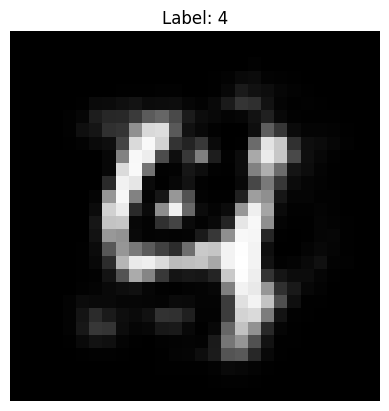

In [53]:
CAE_DENOISE_Model = ConvolutionalAutoencoderDenoise()
CAE_DENOISE_Trainer = CAEDenoise(CAE_DENOISE_Model, MNIST_trainloader_noisy, MNIST_testloader_noisy, lr=0.001, num_epochs=20, device='mps', imshow_func=imshow)

LAE_DENOISE_Trainer.load_model() 
CAE_DENOISE_Trainer.load_model()

device = torch.device("mps")
LAE_DENOISE_Model = LAE_DENOISE_Model.to(device)
CAE_DENOISE_Model = CAE_DENOISE_Model.to(device)

# ================== Create Datasets ==================
LAEDenoise_dataloader = create_reconstructed_dataloader(LAE_DENOISE_Model, MNIST_testloader_noisy, torch.device("mps"))
CAEDenoise_dataloader = create_reconstructed_dataloader(CAE_DENOISE_Model, MNIST_testloader_noisy, torch.device("mps"))

data_iter = iter(LAEDenoise_dataloader)

inputs, labels = next(data_iter)

print("Inputs shape:", inputs.shape)
print("Labels:", labels)

data_iter = iter(LAEDenoise_dataloader)
images, labels = next(data_iter)

itemm = 4
img = images[itemm]

if img.shape[0] == 1:
    plt.imshow(img.squeeze().cpu().numpy(), cmap='gray')

plt.title(f"Label: {labels[itemm]}")
plt.axis("off")
plt.show()

<hr>

### <h1 style="text-align: left;"> Class | <span style="color: #9370DB;">Convolutional Neural Network Denoising</span></h1>

<hr>

In [65]:
class CNNDenoise(nn.Module):
    def __init__(self):
        super(CNNDenoise, self).__init__()
        # ===================== YOUR CODE HERE ======================
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1), 
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)                              
        )
        self.decoder = nn.Sequential(
            nn.Flatten(),                          
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, 10)                         
        )
        # =========================================================== 
        
    def forward(self, x):
        # ===================== YOUR CODE HERE ======================
        x = self.encoder(x)
        x = self.decoder(x)
        return x
        # =========================================================== 

<hr>

### <h1 style="text-align: left;">Class | <span style="color: #9370DB;">CNN Classifier Denoising</span></h1>

<hr>

In [ ]:
class CNNClassifierDenoise:
    def __init__(self, model, train_loader, test_loader, LAEDenoise_loader, CAEDenoise_loader, lr=0.001, num_epochs=20, device=None):
        """
        Initializes the CNN classifier for original and denoised datasets.

        Args:
            model (nn.Module): The CNN model.
            train_loader (DataLoader): Training dataset loader.
            test_loader (DataLoader): Test dataset loader.
            LAEDenoise_loader (DataLoader): DataLoader for LAE denoised images.
            CAEDenoise_loader (DataLoader): DataLoader for CAE denoised images.
            lr (float): Learning rate.
            num_epochs (int): Number of training epochs.
            device (str or None): 'cuda' or 'cpu', auto-detect if None.
        """
        self.name = "CNN Classifier Denoising"
        # ===================== YOUR CODE HERE ======================

        self.device = torch.device(device)
            
        self.model = model.to(self.device)
        self.train_loader = train_loader
        self.test_loader = test_loader
        self.LAEDenoise_loader = LAEDenoise_loader
        self.CAEDenoise_loader = CAEDenoise_loader
        self.lr = lr
        self.num_epochs = num_epochs
        
        self.criterion = nn.CrossEntropyLoss()
        self.optimizer = optim.Adam(self.model.parameters(), lr=self.lr)
        # =========================================================== 
    
    def train(self):
        """
        Trains the CNN classifier for a specified number of epochs.
        """
        # ===================== YOUR CODE HERE ======================
        self.model.train()
        train_loss_list = []
        train_accuracy_list = []
        test_loss_list = []
        test_accuracy_list = []

        for epoch in range(1, self.num_epochs + 1):
            running_loss = 0.0
            all_train_preds = []
            all_train_labels = []
            for images, labels in self.train_loader:
                images = images.to(self.device)
                labels = labels.to(self.device)
                self.optimizer.zero_grad()
                outputs = self.model(images)
                loss = self.criterion(outputs, labels)
                loss.backward()
                self.optimizer.step()
                running_loss += loss.item() * images.size(0)
                preds = torch.argmax(outputs, dim=1)
                all_train_preds.extend(preds.cpu().numpy())
                all_train_labels.extend(labels.cpu().numpy())
            epoch_train_loss = running_loss / len(self.train_loader.dataset)
            train_accuracy = accuracy_score(all_train_labels, all_train_preds)
            train_loss_list.append(epoch_train_loss)
            train_accuracy_list.append(train_accuracy)
            
            test_metrics = self.evaluate(self.test_loader, print_results=False)
            test_loss = test_metrics["loss"]
            test_accuracy = test_metrics["accuracy"]
            test_loss_list.append(test_loss)
            test_accuracy_list.append(test_accuracy)
            
            print(f"Epoch {epoch}/{self.num_epochs} | Train Loss: {epoch_train_loss:.4f} | "f"Train Accuracy: {train_accuracy:.4f} | Test Loss: {test_loss:.4f} | "f"Test Accuracy: {test_accuracy:.4f}")
    
        # =========================================================== 
    
    def evaluate(self, dataloader, print_results=True, epoch=None):
        """
        Evaluates the CNN model on a given dataset.

        Args:
            dataloader (DataLoader): The dataset loader to evaluate on.
            print_results (bool): Whether to print evaluation metrics.
            epoch (int or None): Current epoch number if evaluating during training.

        Returns:
            dict: Contains loss, accuracy, precision, recall, f1-score, and confusion matrix.
        """
        # ===================== YOUR CODE HERE ======================
        self.model.eval()
        total_loss = 0.0
        all_preds = []
        all_labels = []
        
        with torch.no_grad():
            for images, labels in dataloader:
                images = images.to(self.device)
                labels = labels.to(self.device)
                outputs = self.model(images)
                loss = self.criterion(outputs, labels)
                total_loss += loss.item() * images.size(0)
                preds = torch.argmax(outputs, dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        
        avg_loss = total_loss / len(dataloader.dataset)
        accuracy = accuracy_score(all_labels, all_preds)
        precision = precision_score(all_labels, all_preds, average='macro')
        recall = recall_score(all_labels, all_preds, average='macro')
        f1 = f1_score(all_labels, all_preds, average='macro')
        cm = confusion_matrix(all_labels, all_preds)
        
        metrics = {
            "loss": avg_loss,
            "accuracy": accuracy,
            "precision": precision,
            "recall": recall,
            "f1_score": f1,
            "confusion_matrix": cm
        }
        
        if print_results:
            print("Evaluation Metrics:")
            if epoch is not None:
                print(f"Epoch {epoch}:")
            print(f"Loss: {avg_loss:.4f}")
            print(f"Accuracy: {accuracy:.4f}")
            print(f"Precision: {precision:.4f}")
            print(f"Recall: {recall:.4f}")
            print(f"F1 Score: {f1:.4f}")
            print("Confusion Matrix:")
            print(cm)
        
        return metrics
        # =========================================================== 
    
    def save_model(self, path="CNN_Denoise.pth"):
        """
        Saves the trained model to the specified file path.

        Args:
            path (str): File path to save the model.
        """
        torch.save(self.model.state_dict(), path)
        print(f"Model saved to {path}")
    
    def load_model(self, path="CNN_Denoise.pth"):
        """
        Loads the trained model from the specified file path.

        Args:
            path (str): File path of the saved model.
        """
        self.model.load_state_dict(torch.load(path, map_location=self.device))
        self.model.to(self.device)
        print(f"Model loaded from {path}")

<hr>

### <h1 style="text-align: left;">Model Setup | <span style="color: #9370DB;">CNN Classifier Denoising</span></h1>

<hr>

In [67]:
CNN_DENOISE_Model = CNNDenoise()
CNN_CLASSIFIER_DENOISE_Trainer = CNNClassifierDenoise(model=CNN_DENOISE_Model,train_loader=MNIST_trainloader,test_loader=MNIST_testloader,LAEDenoise_loader=LAEDenoise_dataloader,CAEDenoise_loader=CAEDenoise_dataloader,lr=0.001,num_epochs=10,device='mps')

<hr>

### <h1 style="text-align: left;">Training | <span style="color: #9370DB;">CNN Classifier Denoising</span></h1>

<hr>

In [68]:
# ===================== YOUR CODE HERE ======================
CNN_CLASSIFIER_DENOISE_Trainer.train()
# ===========================================================

Epoch 1/10 | Train Loss: 0.2400 | Train Accuracy: 0.9296 | Test Loss: 0.0705 | Test Accuracy: 0.9772
Epoch 2/10 | Train Loss: 0.0637 | Train Accuracy: 0.9804 | Test Loss: 0.0416 | Test Accuracy: 0.9853
Epoch 3/10 | Train Loss: 0.0439 | Train Accuracy: 0.9866 | Test Loss: 0.0372 | Test Accuracy: 0.9884
Epoch 4/10 | Train Loss: 0.0348 | Train Accuracy: 0.9891 | Test Loss: 0.0322 | Test Accuracy: 0.9896
Epoch 5/10 | Train Loss: 0.0254 | Train Accuracy: 0.9919 | Test Loss: 0.0310 | Test Accuracy: 0.9899
Epoch 6/10 | Train Loss: 0.0209 | Train Accuracy: 0.9934 | Test Loss: 0.0294 | Test Accuracy: 0.9900
Epoch 7/10 | Train Loss: 0.0163 | Train Accuracy: 0.9950 | Test Loss: 0.0315 | Test Accuracy: 0.9902
Epoch 8/10 | Train Loss: 0.0128 | Train Accuracy: 0.9957 | Test Loss: 0.0306 | Test Accuracy: 0.9902
Epoch 9/10 | Train Loss: 0.0117 | Train Accuracy: 0.9962 | Test Loss: 0.0283 | Test Accuracy: 0.9915
Epoch 10/10 | Train Loss: 0.0089 | Train Accuracy: 0.9972 | Test Loss: 0.0282 | Test Accura

<hr>

### <h1 style="text-align: left;">Results | <span style="color: #9370DB;">CNN Classifier Denoising</span></h1>

<hr>

In [69]:
# ===================== YOUR CODE HERE ======================
CNN_CLASSIFIER_DENOISE_Trainer.save_model() 
CNN_CLASSIFIER_DENOISE_Trainer.evaluate(MNIST_testloader, print_results=True)
CNN_CLASSIFIER_DENOISE_Trainer.evaluate(LAEDenoise_dataloader, print_results=True)
CNN_CLASSIFIER_DENOISE_Trainer.evaluate(CAEDenoise_dataloader, print_results=True)
# ===========================================================

Overall_Results["Task 6"] = {
    "Train Loss (Last Epoch)": 0.0089,
    "Test Loss (Last Epoch)": 0.0282,
    "Train Accuracy (Last Epoch)": 0.9972,
    "Test Accuracy (Last Epoch)": 0.9913,
    "Train Loss (Minimum)": 0.0089,
    "Test Loss (Minimum)": 0.0282,
    "Train Accuracy (Maximum)": 0.9972,
    "Test Accuracy (Maximum)": 0.9915,
}

Model saved to CNN_Denoise.pth
Evaluation Metrics:
Loss: 0.0282
Accuracy: 0.9913
Precision: 0.9913
Recall: 0.9912
F1 Score: 0.9912
Confusion Matrix:
[[ 977    0    0    0    0    1    0    0    1    1]
 [   0 1135    0    0    0    0    0    0    0    0]
 [   1    0 1022    1    0    0    1    4    3    0]
 [   1    0    0 1005    0    2    0    0    2    0]
 [   0    1    0    0  966    0    1    1    1   12]
 [   2    0    0    4    0  885    1    0    0    0]
 [   5    2    1    0    1    0  944    0    5    0]
 [   0    0    7    0    0    0    0 1017    1    3]
 [   2    0    2    1    0    2    0    1  962    4]
 [   0    0    0    0    2    4    0    2    1 1000]]
Evaluation Metrics:
Loss: 0.1884
Accuracy: 0.9444
Precision: 0.9458
Recall: 0.9442
F1 Score: 0.9443
Confusion Matrix:
[[ 960    0    3    0    0    8    3    2    2    2]
 [   0 1079    4   14    3    5    0   19    8    3]
 [   6    0  970   30    2    0    3   10    9    2]
 [   2    0    1  993    0    7    0    2  

<hr>

### <h1 style="text-align: left;">Analysis | <span style="color: #9370DB;">CNN Classifier Denoising</span></h1>

<hr>

The cnn denoise model was evaluated on three different denoised datasets. In the test evaluation, the model performed exceptionally well with an accuracy of 99.13% and extremely low loss (0.0282), along with nearly perfect precision, recall, and F1 scores. The confusion matrix for this case shows very few misclassifications, suggesting that this denoising approach was very effective at removing noise while preserving key features needed for classification.

In the evaluation om LAEDenoise dataset, the classifier’s performance was slightly lower with an accuracy of 94.44% and a loss of 0.1884. Although the precision, recall, and F1 score remain high, there is a noticeable degradation compared to the best-performing case. This indicates that the denoising process in this instance did not remove noise as effectively, leading to some confusion between classes.

The third evaluation on CAEDenoise dataset shows the lowest performance, with an accuracy of 86.16% and a loss of 0.4653, and the precision, recall, and F1 scores are in the mid-80s. The confusion matrix here reveals more widespread misclassifications, suggesting that the denoising method used in this case was less successful in preserving the discriminative features of the images

<hr>

<hr>

### <h1 style="text-align: left;">Task 6 | <span style="color: #9370DB;">End</span></h1>

<hr>

<hr>

## <h1 style="text-align: left;"><b>Task 7: Classification using Latent Space | <span style="color: #9370DB;">CIFAR-10</span></b></h1>

<hr>

<hr>

### <h1 style="text-align: left;">Class | <span style="color: #9370DB;">Convolutional AutoEncoder</span></h1>

<hr>

In [ ]:
class ConvolutionalAutoencoderLatentSpace(nn.Module):
    def __init__(self):
        super(ConvolutionalAutoencoderLatentSpace, self).__init__()
        # ===================== YOUR CODE HERE ======================
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, stride=2, padding=1),  
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=2, padding=1),  
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=2, padding=1), 
            nn.ReLU(inplace=True)
        )
        
        self.fc_enc = nn.Linear(64 * 4 * 4, 128)
        self.fc_dec = nn.Linear(128, 64 * 4 * 4)
        
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(in_channels=64, out_channels=32, kernel_size=3, stride=2, padding=1, output_padding=0),  
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(in_channels=32, out_channels=16, kernel_size=3, stride=2, padding=1, output_padding=1), 
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(in_channels=16, out_channels=1, kernel_size=3, stride=2, padding=1, output_padding=1),  
            nn.Sigmoid() 
        )
        # ===========================================================

    def forward(self, x):
        # ===================== YOUR CODE HERE ======================
        enc = self.encoder(x)  
        batch_size = enc.size(0)
        enc_flat = enc.view(batch_size, -1)  
        latent = self.fc_enc(enc_flat)         
        
        dec_flat = self.fc_dec(latent)         
        dec_feat = dec_flat.view(batch_size, 64, 4, 4)  
        reconstructed = self.decoder(dec_feat) 
        return reconstructed, latent
        # ===========================================================

<hr>

### <h1 style="text-align: left;">Class | <span style="color: #9370DB;">Trainer + Interpolation</span></h1>

<hr>

### <h2>Interpolation in Latent Space</h2>

<p>Interpolation in an autoencoder's latent space involves generating intermediate representations between two encoded data points. 
In the <code>AutoencoderTrainer</code> class, this is implemented through two methods:</p>

<ul>
    <li><b><code>interpolate_same_class</code></b>: Performs interpolation between two samples of the same class.</li>
    <li><b><code>interpolate_different_classes</code></b>: Interpolates between two samples belonging to different classes.</li>
</ul>

<hr>

<h2>Why Do We Perform Interpolation?</h2>

<ul>
    <li>
        <b>Understanding the Learned Latent Space</b>
        <ul>
            <li>By interpolating between encoded representations, we can analyze how the model organizes and encodes data.</li>
            <li>A well-trained autoencoder should produce smooth transitions between interpolated samples.</li>
        </ul>
    </li>
    <li>
        <b>Semantic Meaning of Latent Representations</b>
        <ul>
            <li>If interpolation results in meaningful intermediate samples, it suggests that the latent space is structured logically.</li>
            <li>For same-class interpolation, a gradual shift should preserve key features of the class.</li>
            <li>For different-class interpolation, the transition should indicate how the model bridges the gap between distinct classes.</li>
        </ul>
    </li>
    <li>
        <b>Evaluating the Decoder</b>
        <ul>
            <li>The reconstructed interpolated samples help determine whether the decoder can generalize well beyond just memorizing training samples.</li>
        </ul>
    </li>
</ul>

<hr>

<h2>How the <code>AutoencoderTrainer</code> Class Implements Interpolation</h2>

<p>In the provided implementation:</p>

<ul>
    <li>The <b>encoder</b> compresses input images into a latent representation.</li>
    <li>Two latent vectors are selected based on class labels.</li>
    <li>Intermediate points are computed using weighted combinations of the two latent vectors.</li>
    <li>The <b>decoder</b> reconstructs images from the interpolated latent representations.</li>
    <li>The function <code>visualize_interpolation</code> helps in analyzing how interpolation affects the generated samples.</li>
</ul>

<p>By running these interpolation methods, one can visually inspect whether the autoencoder has learned a meaningful latent space.</p>

In [ ]:
class AutoencoderTrainer:
    """
    A class to train an autoencoder model and perform latent space interpolations.
    This trainer supports training, latent space interpolations between
    same and different class samples, visualization, and model saving/loading.
    """
    
    def __init__(self, model, device="cuda" if torch.cuda.is_available() else "cpu"):
        """
        Initializes the AutoencoderTrainer.

        Args:
            model: The autoencoder model to be trained and evaluated.
            device: The device to run computations on ("cuda" or "cpu").
        """
        # ===================== YOUR CODE HERE ======================
        self.device = torch.device(device)
        self.model = model.to(self.device)
        self.criterion = nn.MSELoss()
        self.optimizer = optim.Adam(self.model.parameters(), lr=0.001)
        self.train_losses = []
        # ===========================================================
    
    def train(self, train_loader, epochs=10):
        """
        Trains the autoencoder model using mean squared error loss.

        Args:
            train_loader: DataLoader for training dataset.
            epochs: Number of training epochs (default is 10).
        """
        # ===================== YOUR CODE HERE ======================
        self.model.train()
        for epoch in range(1, epochs + 1):
            running_loss = 0.0
            for images, _ in train_loader:
                images = images.to(self.device)
                self.optimizer.zero_grad()
                reconstructed, _ = self.model(images)
                loss = self.criterion(reconstructed, images)
                loss.backward()
                self.optimizer.step()
                running_loss += loss.item() * images.size(0)
            epoch_loss = running_loss / len(train_loader.dataset)
            self.train_losses.append(epoch_loss)
            print(f"Epoch {epoch}/{epochs} | Loss: {epoch_loss:.4f}")
        # ===========================================================
    

    def decode_latent(self, latent):
        x = self.model.fc_dec(latent)
        x = x.view(-1, 64, 4, 4)
        x = self.model.decoder(x)
        return x

    def interpolate_same_class(self, dataloader, steps=10):
        """
        Performs latent space interpolation between two images of the same class.

        Args:
            dataloader: DataLoader containing the dataset.
            steps: Number of interpolation steps (default is 10).

        Returns:
            A tensor containing interpolated images if successful, else None.
        """
        # ===================== YOUR CODE HERE ======================
        self.model.eval()
        images_list, labels_list = next(iter(dataloader))
        images = images_list.to(self.device)
        labels = labels_list.to(self.device)
        chosen_label = labels[0].item()
        idxs = (labels == chosen_label).nonzero(as_tuple=True)[0]
        if len(idxs) < 2:
            return None
        img1 = images[idxs[0]].unsqueeze(0)
        img2 = images[idxs[1]].unsqueeze(0)
        _, latent1 = self.model(img1)
        _, latent2 = self.model(img2)
        interpolated_list = []

        for i in range(steps):
            alpha = i / (steps - 1)
            latent_interp = (1 - alpha) * latent1 + alpha * latent2
            recon = self.decode_latent(latent_interp)
            interpolated_list.append(recon)

        interpolated_images = torch.cat(interpolated_list, dim=0)
        return img1.cpu(), img2.cpu(), interpolated_images.cpu()
        # ===========================================================

    def interpolate_different_classes(self, dataloader, steps=10):
        """
        Performs latent space interpolation between two images of different classes.

        Args:
            dataloader: DataLoader containing the dataset.
            steps: Number of interpolation steps (default is 10).

        Returns:
            A tensor containing interpolated images if successful, else None.
        """
        # ===================== YOUR CODE HERE ======================
        self.model.eval()
        images_list, labels_list = next(iter(dataloader))
        images = images_list.to(self.device)
        labels = labels_list.to(self.device)
        idx1 = 0
        label1 = labels[idx1].item()
        idx2 = None
        for i in range(1, len(labels)):
            if labels[i].item() != label1:
                idx2 = i
                break
        if idx2 is None:
            return None
        img1 = images[idx1].unsqueeze(0)
        img2 = images[idx2].unsqueeze(0)
        _, latent1 = self.model(img1)
        _, latent2 = self.model(img2)
        interpolated_list = []
        for i in range(steps):
            alpha = i / (steps - 1)
            latent_interp = (1 - alpha) * latent1 + alpha * latent2
            recon = self.decode_latent(latent_interp)
            interpolated_list.append(recon)
        interpolated_images = torch.cat(interpolated_list, dim=0)
        return img1.cpu(), img2.cpu(), interpolated_images.cpu()
        # ===========================================================

    def visualize_interpolation(self, img1, img2, interpolated_images, title):
        """
        Visualizes interpolation results between two images.

        Args:
            img1: First image.
            img2: Second image.
            interpolated_images: List of interpolated images.
            title: Title for the visualization.
        """
        # ===================== YOUR CODE HERE ======================
        num_steps = interpolated_images.size(0)
        plt.figure(figsize=(15, 5))
        plt.subplot(1, num_steps + 2, 1)
        plt.imshow(img1.squeeze().cpu().numpy(), cmap='gray')
        plt.title("Image 1")
        plt.axis("off")
        for i in range(num_steps):
            plt.subplot(1, num_steps + 2, i + 2)
            plt.imshow(interpolated_images[i].detach().squeeze().cpu().numpy(), cmap='gray')
            plt.title(f"Step {i+1}")
            plt.axis("off")
        plt.subplot(1, num_steps + 2, num_steps + 2)
        plt.imshow(img2.detach().squeeze().cpu().numpy(), cmap='gray')
        plt.title("Image 2")
        plt.axis("off")
        plt.suptitle(title)
        plt.show()
        # ===========================================================
        
    def save_model(self, path="./models/CAE_LATENT_SPACE.pth"):
        """
        Saves the model state to the specified file.

        Args:
            path: File path where the model will be saved.
        """
        torch.save(self.model.state_dict(), path)
        print(f"Model saved to {path}")

    def load_model(self, path="/models/CAE_LATENT_SPACE.pth"):
        """
        Loads the model state from the specified file.

        Args:
            path: File path from where the model will be loaded.
        """
        self.model.load_state_dict(torch.load(path, map_location=self.device))
        self.model.to(self.device)
        print(f"Model loaded from {path}")

<hr>

### <h1 style="text-align: left;">Model Setup | <span style="color: #9370DB;">CAE Latent Space</span></h1>

<hr>

In [99]:
CAE_LATENT_SPACE_Model = ConvolutionalAutoencoderLatentSpace()
CAE_LATENT_SPACE_Trainer = AutoencoderTrainer(CAE_LATENT_SPACE_Model, device="mps")

<hr>

### <h1 style="text-align: left;">Training | <span style="color: #9370DB;">CAE Latent Space</span></h1>

<hr>

In [100]:
# ===================== YOUR CODE HERE ======================
CAE_LATENT_SPACE_Trainer.train(MNIST_trainloader)
# ===========================================================

Epoch 1/10 | Loss: 0.0453
Epoch 2/10 | Loss: 0.0093
Epoch 3/10 | Loss: 0.0061
Epoch 4/10 | Loss: 0.0049
Epoch 5/10 | Loss: 0.0042
Epoch 6/10 | Loss: 0.0037
Epoch 7/10 | Loss: 0.0033
Epoch 8/10 | Loss: 0.0031
Epoch 9/10 | Loss: 0.0028
Epoch 10/10 | Loss: 0.0027


<hr>

### <h1 style="text-align: left;">Interpolation | <span style="color: #9370DB;">CAE Latent Space</span></h1>

<hr>

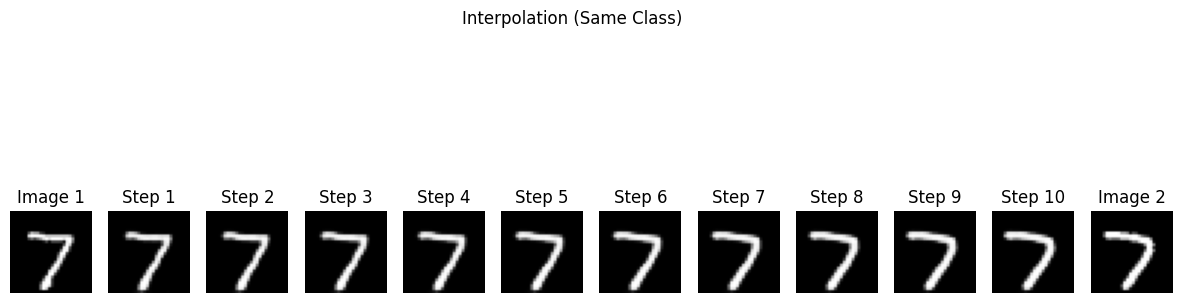

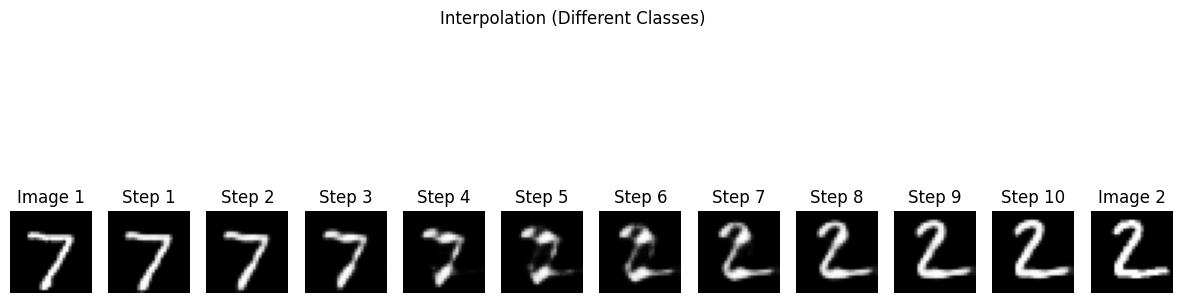

Model saved to ./models/CAE_LATENT_SPACE.pth


In [101]:
# ===================== YOUR CODE HERE ======================
img1, img2, interp_same = CAE_LATENT_SPACE_Trainer.interpolate_same_class(MNIST_testloader, steps=10)
CAE_LATENT_SPACE_Trainer.visualize_interpolation(img1, img2, interp_same, title="Interpolation (Same Class)")

img1, img2, interp_diff = CAE_LATENT_SPACE_Trainer.interpolate_different_classes(MNIST_testloader, steps=10)
CAE_LATENT_SPACE_Trainer.visualize_interpolation(img1, img2, interp_diff, title="Interpolation (Different Classes)")

CAE_LATENT_SPACE_Trainer.save_model()
# ===========================================================

<hr>

### <h1 style="text-align: left;">Task 7 | <span style="color: #9370DB;">End</span></h1>

<hr>

In [102]:
import json

print(json.dumps(Overall_Results, indent=4))

with open(f'{Experiment_ID}_Overall_Results.json', 'w') as f:
    json.dump(Overall_Results, f, indent=4)

{
    "Task 1": null,
    "Task 2": null,
    "Task 3": {
        "Train Loss (Last Epoch)": null,
        "Test Loss (Last Epoch)": null,
        "Train Loss (Minimum)": null,
        "Test Loss (Minimum)": null
    },
    "Task 4": null,
    "Task 5": {
        "Train Loss (Last Epoch)": null,
        "Test Loss (Last Epoch)": null,
        "Train Accuracy (Last Epoch)": null,
        "Test Accuracy (Last Epoch)": null,
        "Train Loss (Minimum)": null,
        "Test Loss (Minimum)": null,
        "Train Accuracy (Maximum)": null,
        "Test Accuracy (Maximum)": null
    },
    "Task 6": {
        "Train Loss (Last Epoch)": null,
        "Test Loss (Last Epoch)": null,
        "Train Accuracy (Last Epoch)": null,
        "Test Accuracy (Last Epoch)": null,
        "Train Loss (Minimum)": null,
        "Test Loss (Minimum)": null,
        "Train Accuracy (Maximum)": null,
        "Test Accuracy (Maximum)": null
    }
}


<hr>

### <h1 style="text-align: left;">I AM SORRY  <span style="color: #9370DB;"> : ( ( ( ( (</span></h1>

<hr>